Read in the num_sub_master parquet file and perform initial feature engineering like creating a 'ticker' column and removing unneccesary columns

In [4]:
import pandas as pd

In [ ]:
master_import = pd.read_parquet('../data/clean/num_sub_master_recon.parquet')

In [6]:
# Add a column next to instance called `ticker` that contains the stock ticker of the company
# Split the `instance` column on the '-' character and take the first element if it is less or equal to four chars
master_import['ticker'] = master_import['instance'].apply(lambda x: x.split('-')[0] if len(x.split('-')[0]) <= 4 else None)

# Capitalize the ticker column
master_import['ticker'] = master_import['ticker'].str.upper()

master_import.head(5)

,adsh,cik,name,sic,countryba,instance,tag,version,ddate,qtrs,uom,segments,coreg,value,footnote,ticker
0,0001104659-10-006102,812074,OWENS ILLINOIS INC /DE/,3221.0,US,oi-20091231.xml,CashAndCashEquivalentsAtCarryingValue,us-gaap/2009,20071231,0,USD,<NA>,<NA>,3.877000e+08,None,OI
1,0001104659-10-006102,812074,OWENS ILLINOIS INC /DE/,3221.0,US,oi-20091231.xml,StockholdersEquity,us-gaap/2009,20091231,0,USD,<NA>,<NA>,1.538200e+09,None,OI
2,0001104659-10-006102,812074,OWENS ILLINOIS INC /DE/,3221.0,US,oi-20091231.xml,CostOfGoodsAndServicesSold,us-gaap/2009,20091231,4,USD,<NA>,<NA>,5.582600e+09,None,OI
3,0001104659-10-006102,812074,OWENS ILLINOIS INC /DE/,3221.0,US,oi-20091231.xml,ResearchAndDevelopmentExpense,us-gaap/2009,20071231,4,USD,<NA>,<NA>,6.580000e+07,None,OI
4,0001104659-10-006102,812074,OWENS ILLINOIS INC /DE/,3221.0,US,oi-20091231.xml,CashAndCashEquivalentsAtCarryingValue,us-gaap/2009,20091231,0,USD,<NA>,<NA>,8.117000e+08,None,OI


In [7]:
# Get a list of all the unique tickers
unique_tickers = master_import['ticker'].unique()

len(unique_tickers)

16580

In [ ]:
# 16000 is much too long. Let's filter out any tickers that are not part of all_stock_tickers.xlsx

all_stock_tickers = pd.read_excel('../data/clean/all_stock_tickers.xlsx')
all_stock_tickers_list = list(all_stock_tickers['Symbol'])

# Filter out any tickers that are not in all_stock_tickers
master_filtered_1 = master_import[master_import['ticker'].isin(all_stock_tickers_list)]
unique_tickers_filtered_1 = master_filtered_1['ticker'].unique()

In [ ]:
len(unique_tickers_filtered_1)
# 4580 is much better.

4580

Using the list of unique_tickers_filtered_1, get the current market cap (as of 1MAR2025)

In [10]:
# import yfinance as yf

In [11]:
# Define a function that returns the market cap of a given ticker
def get_market_cap(ticker):
    info = yf.Ticker(ticker).get_info()
    return info['marketCap']

In [12]:
# Test the function using known ticker 'AAPL'
# get_market_cap('AAPL')
# Yep, function works

In [13]:
# Define a for loop to iterate through the list of unique_tickers and return a data frame with ticker and market cap
# With 4300+ entries this will take over 2 hours to run... let's further filter the ticker list 
#from time import sleep

#market_caps = pd.DataFrame(columns=['ticker', 'market_cap'])

#for ticker in unique_tickers_filtered_1:
#    sleep(2)
#    try:
#        market_cap = get_market_cap(ticker)
#        market_caps = market_caps._append({'ticker': ticker, 'market_cap': market_cap}, ignore_index=True)
#        print(f'{ticker} market cap: {market_cap}')
#    except:
#        print(f'Could not fetch market cap for {ticker}. Either the ticker does not exist or the API is not working')
#        pass

In [14]:
# We can use the  all_stock_tickers market cap column, an imprecise rounding (as a str) to filter out tickers with a market cap 

# First change the market cap column to a float
# The format of all strings in ths column is '1.23B' or '1.23M' or '1.23K'
# Market cap greater than 999B has a comma in the number
all_stock_tickers_float = all_stock_tickers.copy()
all_stock_tickers_float['Market Cap'] = all_stock_tickers_float['Market Cap'].str.replace(',', '')
all_stock_tickers_float['Market Cap'] = all_stock_tickers_float['Market Cap'].str.replace('B', 'e9').str.replace('M', 'e6').str.replace('K', 'e3').astype(float)

In [15]:
all_stock_tickers_float.head(15)

,Symbol,Company Name,Industry,Market Cap
0,A,"Agilent Technologies, Inc.",Diagnostics & Research,3.862000e+10
1,AA,Alcoa Corporation,Aluminum,8.890000e+09
2,AACB,Artius II Acquisition Inc.,Shell Companies,2.505000e+08
3,AACG,ATA Creativity Global,Education & Training Services,2.911000e+07
4,AACT,Ares Acquisition Corporation II,Shell Companies,6.912500e+08
5,AADI,"Aadi Bioscience, Inc.",Biotechnology,6.877000e+07
6,AAL,American Airlines Group Inc.,Airlines,1.001000e+10
7,AAM,AA Mission Acquisition Corp.,Shell Companies,4.472200e+08
8,AAME,Atlantic American Corporation,Insurance - Life,3.203000e+07
9,AAMI,Acadian Asset Management Inc.,Asset Management,9.594400e+08


In [16]:
# Now, filtering out tickers with a market cap of greater than 3B
#all_stock_tickers_list_filtered = all_stock_tickers_float[(all_stock_tickers_float['Market Cap'] >=250e6) & (all_stock_tickers_float['Market Cap'] <= 2e9)]['Symbol']

In [17]:
#master_filtered_2 = master_filtered_1[master_filtered_1['ticker'].isin(all_stock_tickers_list_filtered)]
#len(master_filtered_2['ticker'].unique())

# 1300 is most manageable

Filter unique 'ddate' 'ticker' and 'tag' pairs

In [18]:
master_filtered_3 = master_filtered_1.copy()
master_filtered_3['ticker_tag_ddate_qtrs'] = master_filtered_3['ticker'].astype(str) + '_' + master_filtered_3['tag'].astype(str) + '_' + master_filtered_3['ddate'].astype(str) + '_' + master_filtered_3['qtrs'].astype(str)
master_filtered_3.head(5)

,adsh,cik,name,sic,countryba,instance,tag,version,ddate,qtrs,uom,segments,coreg,value,footnote,ticker,ticker_tag_ddate_qtrs
0,0001104659-10-006102,812074,OWENS ILLINOIS INC /DE/,3221.0,US,oi-20091231.xml,CashAndCashEquivalentsAtCarryingValue,us-gaap/2009,20071231,0,USD,<NA>,<NA>,3.877000e+08,None,OI,OI_CashAndCashEquivalentsAtCarryingValue_20071...
1,0001104659-10-006102,812074,OWENS ILLINOIS INC /DE/,3221.0,US,oi-20091231.xml,StockholdersEquity,us-gaap/2009,20091231,0,USD,<NA>,<NA>,1.538200e+09,None,OI,OI_StockholdersEquity_20091231_0
2,0001104659-10-006102,812074,OWENS ILLINOIS INC /DE/,3221.0,US,oi-20091231.xml,CostOfGoodsAndServicesSold,us-gaap/2009,20091231,4,USD,<NA>,<NA>,5.582600e+09,None,OI,OI_CostOfGoodsAndServicesSold_20091231_4
3,0001104659-10-006102,812074,OWENS ILLINOIS INC /DE/,3221.0,US,oi-20091231.xml,ResearchAndDevelopmentExpense,us-gaap/2009,20071231,4,USD,<NA>,<NA>,6.580000e+07,None,OI,OI_ResearchAndDevelopmentExpense_20071231_4
4,0001104659-10-006102,812074,OWENS ILLINOIS INC /DE/,3221.0,US,oi-20091231.xml,CashAndCashEquivalentsAtCarryingValue,us-gaap/2009,20091231,0,USD,<NA>,<NA>,8.117000e+08,None,OI,OI_CashAndCashEquivalentsAtCarryingValue_20091...


In [19]:
len(master_filtered_3['ticker_tag_ddate_qtrs'].unique())

1889012

In [20]:
master_filtered_3 = master_filtered_3.drop_duplicates(subset='ticker_tag_ddate_qtrs', keep='first')
len(master_filtered_3['ticker_tag_ddate_qtrs'].unique())

1889012

Remove unnecessary columns 

In [21]:
master_filtered_4 = master_filtered_3.drop(columns=['adsh', 'cik', 'instance','segments','coreg','footnote','ticker_tag_ddate_qtrs', 'uom','version'])

In [22]:
master_filtered_4

,name,sic,countryba,tag,ddate,qtrs,value,ticker
0,OWENS ILLINOIS INC /DE/,3221.0,US,CashAndCashEquivalentsAtCarryingValue,20071231,0,3.877000e+08,OI
1,OWENS ILLINOIS INC /DE/,3221.0,US,StockholdersEquity,20091231,0,1.538200e+09,OI
2,OWENS ILLINOIS INC /DE/,3221.0,US,CostOfGoodsAndServicesSold,20091231,4,5.582600e+09,OI
3,OWENS ILLINOIS INC /DE/,3221.0,US,ResearchAndDevelopmentExpense,20071231,4,6.580000e+07,OI
4,OWENS ILLINOIS INC /DE/,3221.0,US,CashAndCashEquivalentsAtCarryingValue,20091231,0,8.117000e+08,OI
...,...,...,...,...,...,...,...,...
9910564,"WISDOMTREE, INC.",6211.0,US,OperatingIncomeLoss,20240930,1,4.079200e+07,WT
9910566,"WISDOMTREE, INC.",6211.0,US,Revenues,20240930,1,1.131680e+08,WT
9910570,"WISDOMTREE, INC.",6211.0,US,PaymentsToAcquirePropertyPlantAndEquipment,20240930,3,1.280000e+05,WT
9910573,"WISDOMTREE, INC.",6211.0,US,Revenues,20240930,3,3.170400e+08,WT


In [ ]:
# Filter the DataFrame for rows where the 'tag' column is 'Revenue'
qtrs_filter_df = master_filtered_4[master_filtered_4['tag'] == 'RevenueFromContractWithCustomerExcludingAssessedTax']

# Display the value counts of the 'qtrs' column for the filtered rows
qtrs_value_counts = qtrs_filter_df['qtrs'].value_counts()
print(qtrs_value_counts)

qtrs
1     36286
4     12111
3     11123
2     10803
0        40
7         1
8         1
35        1
36        1
37        1
38        1
39        1
40        1
41        1
42        1
Name: count, dtype: int64


Need to decide how to handle the different 'qtrs' amounts. 

Preferably we can take all the 1s only, so let's find out if all the tags have qtr 1

In [24]:
def get_tag_qtrs(df, tag):
    # Filter the DataFrame for rows where the 'tag' column matches the specified tag
    filtered_df = df[df['tag'] == tag]
    
    # Get the value counts of the 'qtrs' column for the filtered rows
    qtrs_value_counts = filtered_df['qtrs'].value_counts()
    
    # Return the tag and the value counts as a tuple
    return (tag, qtrs_value_counts)

# Example usage
result = get_tag_qtrs(master_filtered_4, 'RevenueFromContractWithCustomerExcludingAssessedTax')
print(result)

('RevenueFromContractWithCustomerExcludingAssessedTax', qtrs
1     36286
4     12111
3     11123
2     10803
0        40
7         1
8         1
35        1
36        1
37        1
38        1
39        1
40        1
41        1
42        1
Name: count, dtype: int64)


In [25]:
# Get the count of qtrs for each tag    
for tag in master_filtered_4['tag'].unique():
    result = get_tag_qtrs(master_filtered_4, tag)
    print(result)

('CashAndCashEquivalentsAtCarryingValue', qtrs
0    145970
Name: count, dtype: int64)
('StockholdersEquity', qtrs
0    143836
Name: count, dtype: int64)
('CostOfGoodsAndServicesSold', qtrs
1     32438
4     11965
3     10700
2     10599
0        13
11        2
16        2
14        2
68        1
5         1
76        1
7         1
75        1
74        1
73        1
70        1
71        1
69        1
84        1
13        1
83        1
81        1
51        1
17        1
Name: count, dtype: int64)
('ResearchAndDevelopmentExpense', qtrs
1      37509
4      14878
2      12721
3      12414
0         25
       ...  
98         1
94         1
92         1
96         1
109        1
Name: count, Length: 95, dtype: int64)
('CommonStockSharesOutstanding', qtrs
0    97328
Name: count, dtype: int64)
('PaymentsToAcquirePropertyPlantAndEquipment', qtrs
4      32053
1      30663
2      29037
3      28788
0         69
       ...  
85         1
132        1
82         1
140        1
109        1
Name

In [26]:
# Let's test the difference in values between qtrs for the same tag
test_qtrs_df = master_filtered_4[(master_filtered_4['tag'] == 'RevenueFromContractWithCustomerExcludingAssessedTax') & (master_filtered_4['ticker'] == 'GDYN')]
test_qtrs_df

,name,sic,countryba,tag,ddate,qtrs,value,ticker
7693134,"GRID DYNAMICS HOLDINGS, INC.",7372.0,US,RevenueFromContractWithCustomerExcludingAssess...,20200930,3,81157000.0,GDYN
7693153,"GRID DYNAMICS HOLDINGS, INC.",7372.0,US,RevenueFromContractWithCustomerExcludingAssess...,20200930,1,26332000.0,GDYN
7693162,"GRID DYNAMICS HOLDINGS, INC.",7372.0,US,RevenueFromContractWithCustomerExcludingAssess...,20210930,1,57933000.0,GDYN
7693166,"GRID DYNAMICS HOLDINGS, INC.",7372.0,US,RevenueFromContractWithCustomerExcludingAssess...,20210930,3,144743000.0,GDYN
7871327,"GRID DYNAMICS HOLDINGS, INC.",7372.0,US,RevenueFromContractWithCustomerExcludingAssess...,20191231,4,118326000.0,GDYN
7871345,"GRID DYNAMICS HOLDINGS, INC.",7372.0,US,RevenueFromContractWithCustomerExcludingAssess...,20201231,4,111283000.0,GDYN
7871346,"GRID DYNAMICS HOLDINGS, INC.",7372.0,US,RevenueFromContractWithCustomerExcludingAssess...,20211231,4,211280000.0,GDYN
8039844,"GRID DYNAMICS HOLDINGS, INC.",7372.0,US,RevenueFromContractWithCustomerExcludingAssess...,20210331,1,39134000.0,GDYN
8039866,"GRID DYNAMICS HOLDINGS, INC.",7372.0,US,RevenueFromContractWithCustomerExcludingAssess...,20220331,1,71410000.0,GDYN
8239195,"GRID DYNAMICS HOLDINGS, INC.",7372.0,US,RevenueFromContractWithCustomerExcludingAssess...,20210630,1,47676000.0,GDYN


In [27]:
# It looks like every tag has a qtrs count of 1 except for CashAndCashEquivalentsAtCarryingValue and StockholdersEquity.
# Let's filter to keep tags with a qtrs=1 unless the tag is 
# CashAndCashEquivalentsAtCarryingValue or StockholdersEquity in which case we keep qtrs=0
master_filtered_5 = master_filtered_4[(master_filtered_4['qtrs'] == 1) | ((master_filtered_4['tag'] == 'CashAndCashEquivalentsAtCarryingValue') | (master_filtered_4['tag'] == 'StockholdersEquity'))]

Pivot the tags into columns of their own

In [28]:
master_filtered_6 = master_filtered_5.copy()

# Set the additional columns as part of the index before pivoting
master_filtered_6.set_index(['ddate', 'ticker', 'name', 'sic', 'countryba'], inplace=True)

# Perform the pivot operation
master_filtered_6 = master_filtered_6.pivot(columns='tag', values='value')

# Reset the index to include the additional columns back in the DataFrame
master_filtered_6.reset_index(inplace=True)

# Filter year 2010 and later
master_filtered_6 = master_filtered_6[master_filtered_6['ddate'] > 20091231]

# Filter for US companies
master_filtered_6 = master_filtered_6[master_filtered_6['countryba'] == 'US']

# Order the data frame by ticker alphabetically and then by date
master_filtered_6.sort_values(by=['ddate','ticker'], inplace=True)

master_filtered_6.head(20)

tag,ddate,ticker,name,sic,countryba,CapitalExpenditures,CashAndCashEquivalentsAtCarryingValue,CashFlowsFromUsedInOperatingActivities,CashFlowsFromUsedInOperations,CostOfGoodsAndServicesSold,...,OperatingCosts,OperatingIncomeLoss,PaymentsToAcquirePropertyPlantAndEquipment,ResearchAndDevelopmentExpense,RevenueFromContractWithCustomerExcludingAssessedTax,Revenues,SellingGeneralAndAdministrativeExpense,SellingGeneralAndAdministrativeExpenseExcludingDepreciationDepletionAndAmortization,SellingGeneralAndAdministrativeExpenses,StockholdersEquity
7276,20100131,A,AGILENT TECHNOLOGIES INC,3825.0,US,NaN,2.481000e+09,NaN,NaN,NaN,...,NaN,94000000.0,25000000.0,149000000.0,NaN,NaN,417000000.0,NaN,NaN,2.590000e+09
7277,20100131,ABM,ABM INDUSTRIES INC /DE/,7340.0,US,NaN,2.117700e+07,NaN,NaN,NaN,...,NaN,22206000.0,7379000.0,NaN,NaN,NaN,62802000.0,NaN,NaN,NaN
7278,20100131,ADI,ANALOG DEVICES INC,3674.0,US,NaN,9.142680e+08,NaN,NaN,2.345070e+08,...,NaN,149114000.0,17179000.0,114398000.0,NaN,NaN,88481000.0,NaN,NaN,2.764153e+09
7279,20100131,ADSK,AUTODESK INC,7372.0,US,NaN,8.387000e+08,NaN,NaN,NaN,...,NaN,56000000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.473500e+09
7280,20100131,AEO,AMERICAN EAGLE OUTFITTERS INC,5651.0,US,NaN,6.939600e+08,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.578517e+09
7281,20100131,AGX,ARGAN INC,1700.0,US,NaN,6.615300e+07,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7282,20100131,AIM,AEROSONIC CORP /DE/,3812.0,US,NaN,0.000000e+00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.720000e+06
7283,20100131,ALOT,ASTRO MED INC /NEW/,3577.0,US,NaN,1.415510e+07,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7284,20100131,AMAT,APPLIED MATERIALS INC /DE,3674.0,US,NaN,1.399054e+09,NaN,NaN,1.137718e+09,...,NaN,116343000.0,NaN,269003000.0,NaN,NaN,NaN,NaN,NaN,7.148143e+09
7285,20100131,AMBA,AMBARELLA INC,3674.0,US,NaN,2.659900e+07,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.743300e+07


In [29]:
len(master_filtered_6)

152119

Great! Almost there. In the head there is quite a few missing values, likely because the 2009 in particular was sparse.

Let's create a missingmap

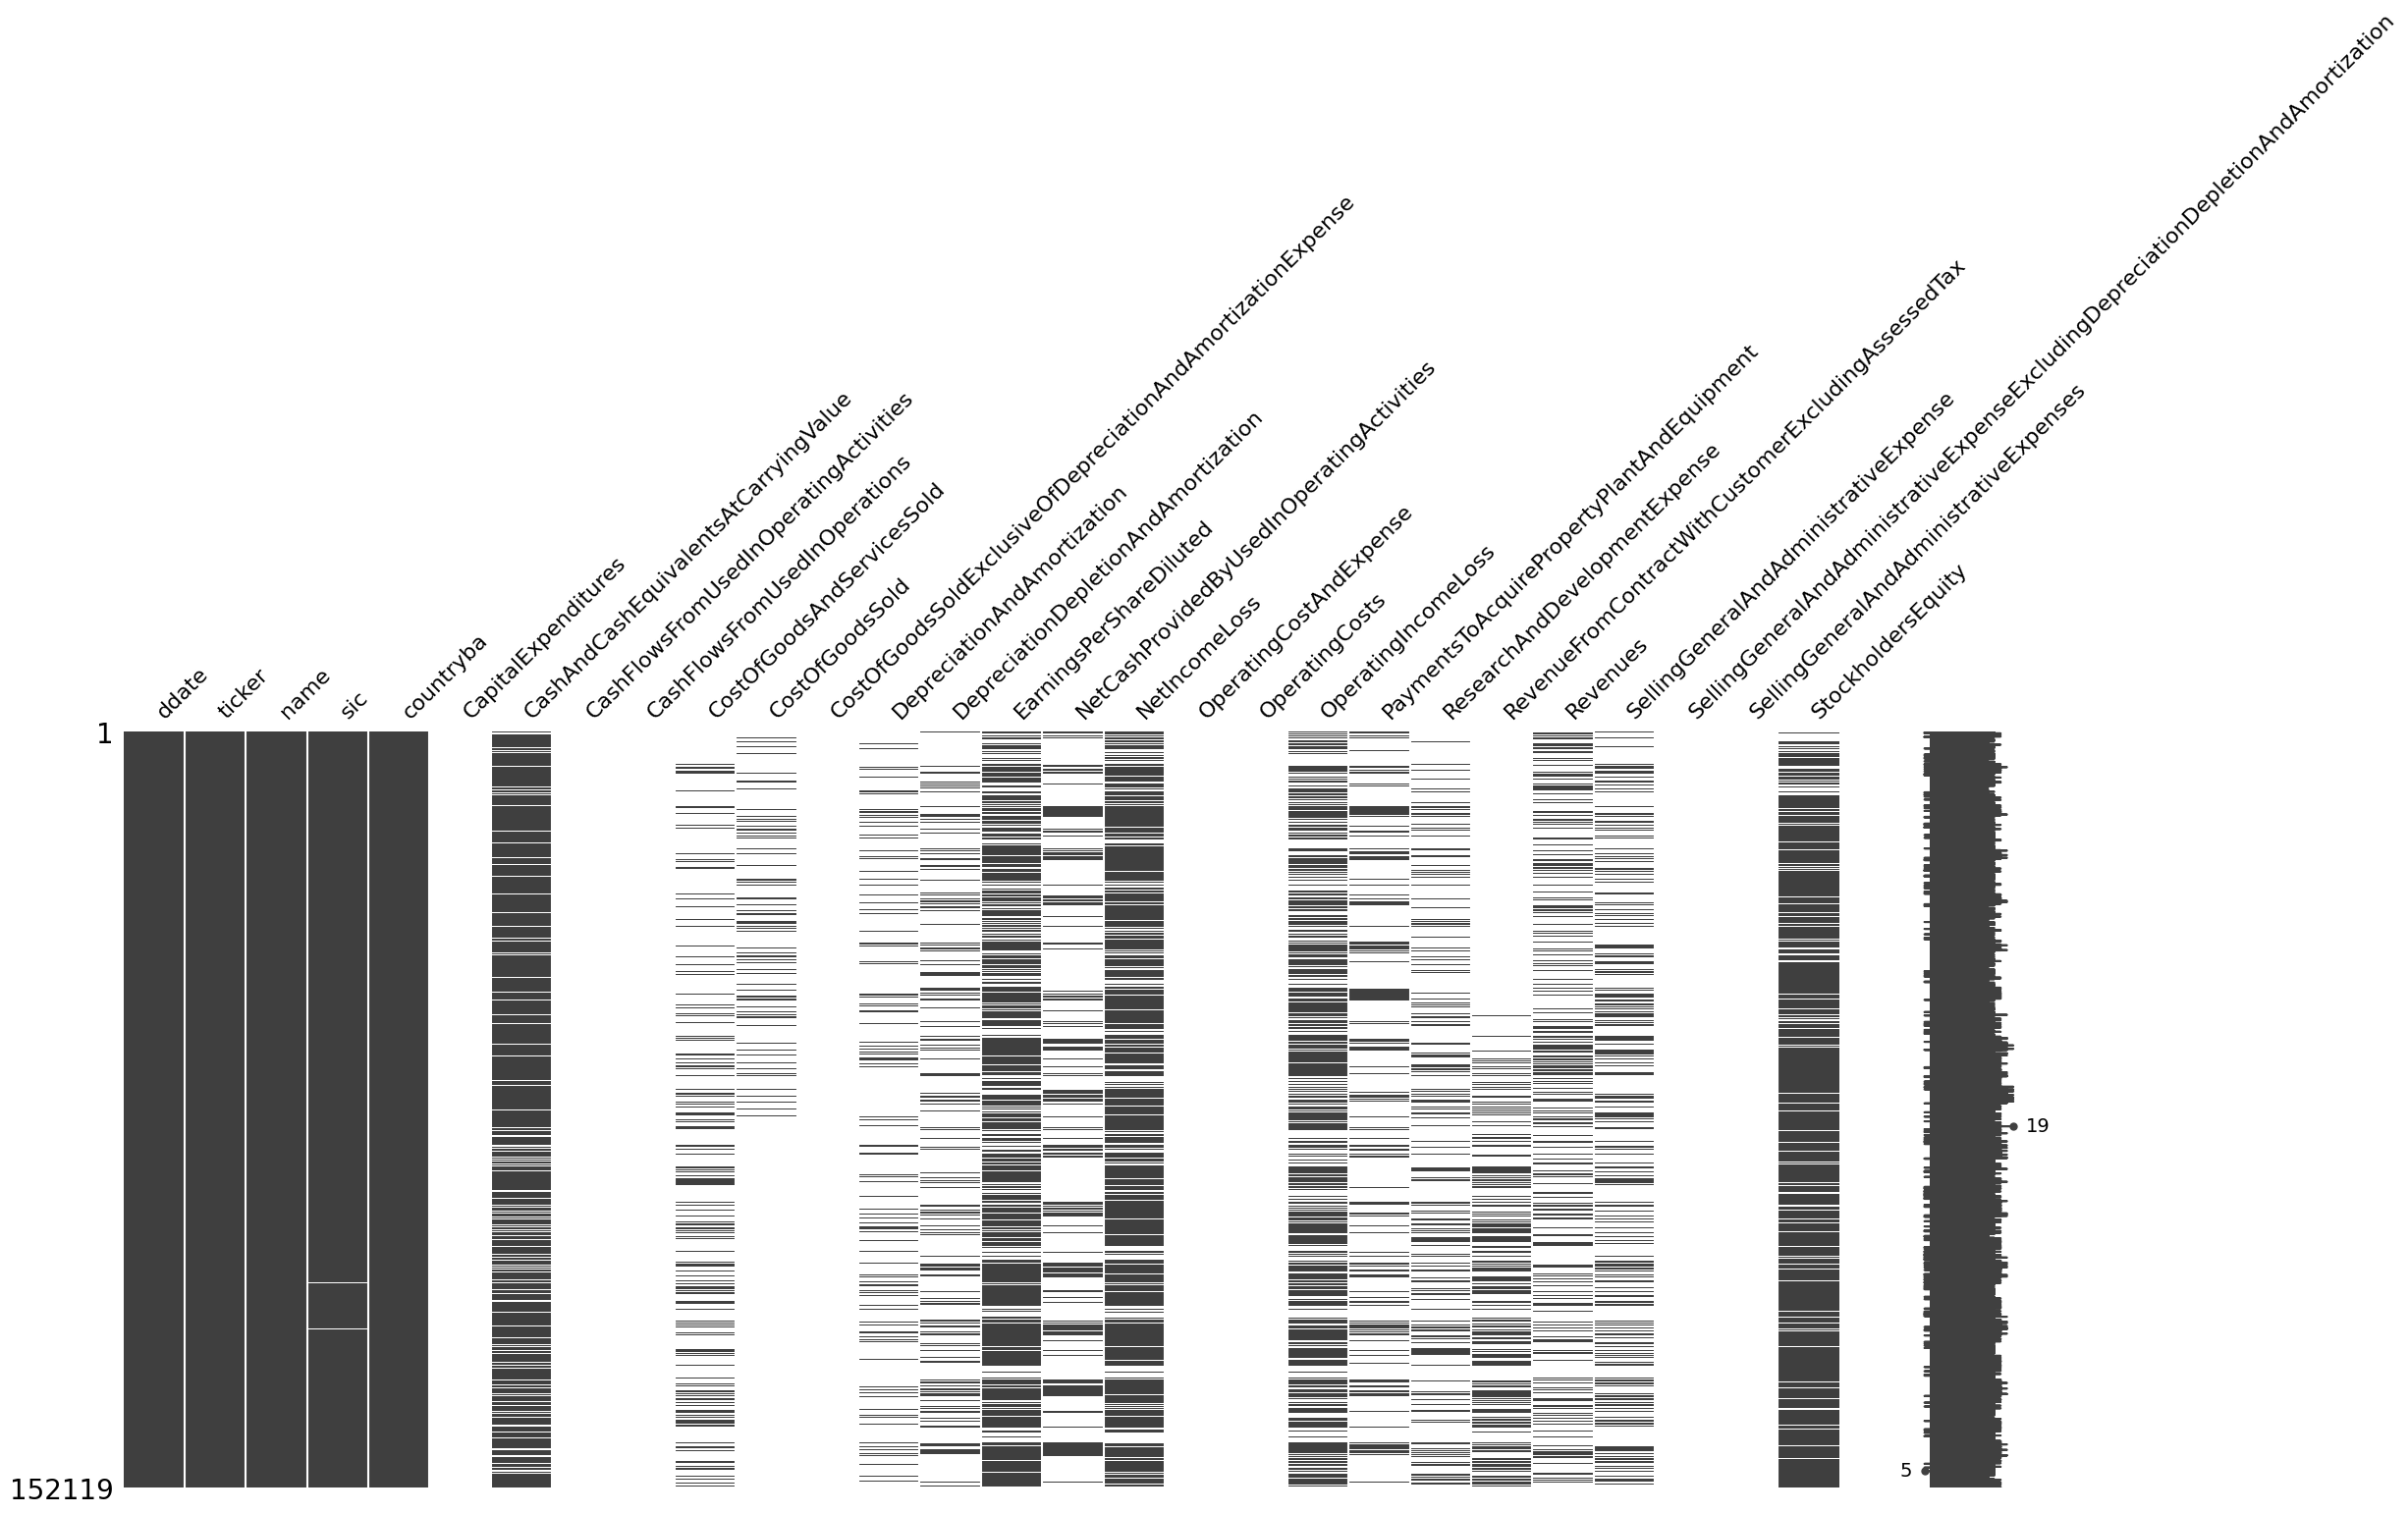

In [30]:
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(master_filtered_6)
plt.show()


In [31]:
# Spot check that Revenues is a matching proxy for RevenueFromContractWithCustomerExcludingAssessedTax in case of missing data
spotcheck_rev_matches_rev = master_filtered_6.dropna(subset=['RevenueFromContractWithCustomerExcludingAssessedTax', 'Revenues'])
print(spotcheck_rev_matches_rev[['RevenueFromContractWithCustomerExcludingAssessedTax', 'Revenues']].head(20))

# yay they in almost all cases match perfectly in instances where both exist

tag    RevenueFromContractWithCustomerExcludingAssessedTax      Revenues
61918                                       3.347500e+07    3.347500e+07
64582                                       3.439600e+07    3.439600e+07
67208                                       3.395200e+07    3.395200e+07
68355                                       8.953000e+08    8.953000e+08
69490                                       1.789000e+08    1.775000e+08
69833                                       3.303700e+07    3.303700e+07
70143                                       6.762000e+08    5.841000e+08
70599                                       2.809900e+10    2.809900e+10
70637                                       1.990000e+05    1.990980e+05
71025                                       8.926000e+08    8.926000e+08
71475                                       1.041700e+07    1.041700e+07
72220                                       9.269000e+06    9.269000e+06
72305                                       1.96700

In [32]:
# Combine the columns 'RevenueFromContractWithCustomerExcludingAssessedTax' and 'Revenues'
# Use the values from 'Revenues' where 'RevenueFromContractWithCustomerExcludingAssessedTax' is NaN
master_filtered_6['TopLineRevenue'] = master_filtered_6['RevenueFromContractWithCustomerExcludingAssessedTax'].fillna(master_filtered_6['Revenues'])

spotcheck_rev_matches_rev_2 = master_filtered_6.dropna(subset=['RevenueFromContractWithCustomerExcludingAssessedTax', 'Revenues', 'TopLineRevenue'])
print(spotcheck_rev_matches_rev_2[['RevenueFromContractWithCustomerExcludingAssessedTax', 'Revenues', 'TopLineRevenue']].head(20))

tag    RevenueFromContractWithCustomerExcludingAssessedTax      Revenues  \
61918                                       3.347500e+07    3.347500e+07   
64582                                       3.439600e+07    3.439600e+07   
67208                                       3.395200e+07    3.395200e+07   
68355                                       8.953000e+08    8.953000e+08   
69490                                       1.789000e+08    1.775000e+08   
69833                                       3.303700e+07    3.303700e+07   
70143                                       6.762000e+08    5.841000e+08   
70599                                       2.809900e+10    2.809900e+10   
70637                                       1.990000e+05    1.990980e+05   
71025                                       8.926000e+08    8.926000e+08   
71475                                       1.041700e+07    1.041700e+07   
72220                                       9.269000e+06    9.269000e+06   
72305       

In [33]:
# Remove the columns 'RevenueFromContractWithCustomerExcludingAssessedTax' and 'Revenues'
master_filtered_7 = master_filtered_6.drop(columns=['RevenueFromContractWithCustomerExcludingAssessedTax', 'Revenues'])

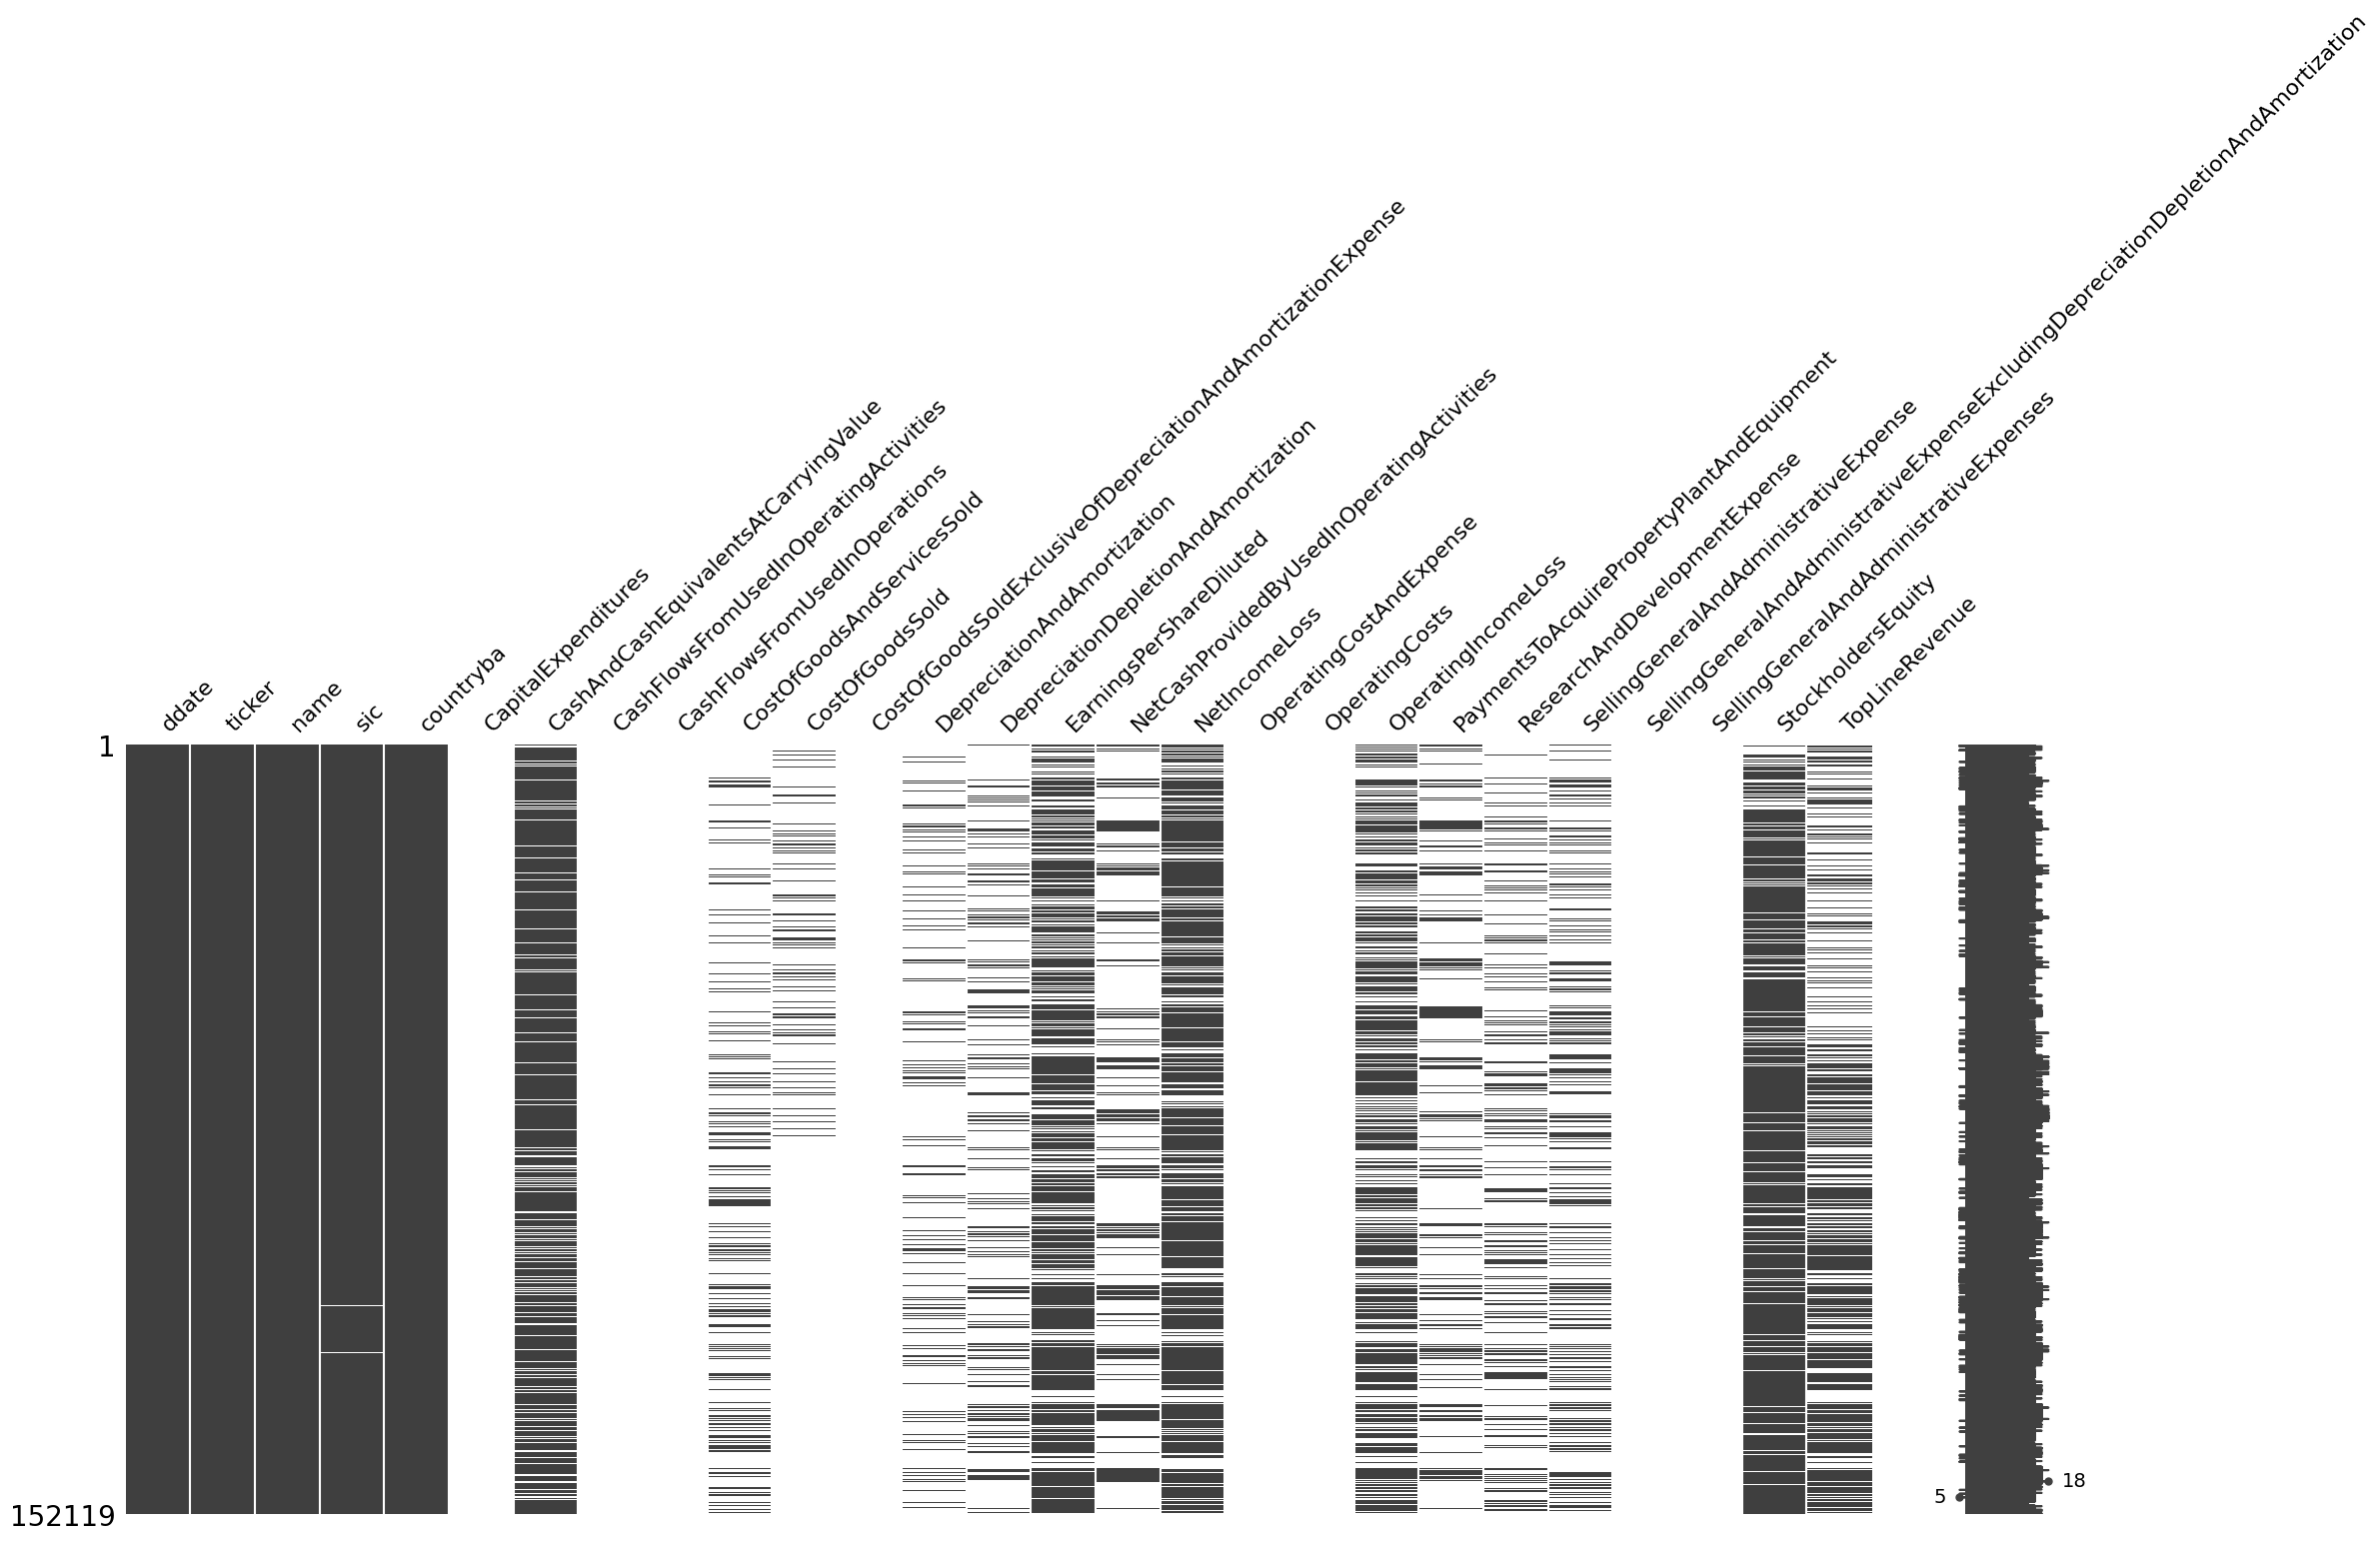

In [34]:
# Run missingno again
msno.matrix(master_filtered_7)
plt.show()

In [35]:
test_same = master_filtered_6.dropna(subset=['CostOfGoodsAndServicesSold', 'CostOfGoodsSold'])
print(test_same[['CostOfGoodsAndServicesSold', 'CostOfGoodsSold']].head(10))

tag   CostOfGoodsAndServicesSold  CostOfGoodsSold
7278                2.345070e+08     2.345070e+08
7297                9.571600e+07     7.666900e+07
7332                1.053690e+08     4.388320e+08
7419                1.052060e+08     8.912300e+07
7608                1.594100e+07     1.291100e+07
7675                4.609890e+08     1.922770e+08
7766                4.141600e+07     2.741900e+07
7851                4.401600e+07     4.101000e+07
7859                5.982000e+09     4.787000e+09
7891                5.995300e+07     5.293900e+07


In [36]:
# Drop blank columns. Drop countryba because all values are US
master_filtered_8 = master_filtered_7.drop(columns=['countryba','CostOfGoodsSold','OperatingCostAndExpense',
                                           'SellingGeneralAndAdministrativeExpenseExcludingDepreciationDepletionAndAmortization',
                                           'SellingGeneralAndAdministrativeExpenses','CashFlowsFromUsedInOperatingActivities',
                                           'CashFlowsFromUsedInOperations'])

In [37]:
# Spot check that D&A is a matching proxy for DD&A in case of missing data
spotcheck_rev_matches_rev = master_filtered_6.dropna(subset=['DepreciationAndAmortization', 'DepreciationDepletionAndAmortization'])
print(spotcheck_rev_matches_rev[['DepreciationAndAmortization', 'DepreciationDepletionAndAmortization']].head(20))

tag   DepreciationAndAmortization  DepreciationDepletionAndAmortization
7414                  488000000.0                           488000000.0
7488                    7066000.0                             7066000.0
7512                  638498000.0                           638498000.0
7548                   52102000.0                            52566000.0
7562                  -73061000.0                            75657000.0
7580                   83075000.0                            83075000.0
7592                   72883000.0                            70449000.0
7602                   16753000.0                            16753000.0
7643                   42968000.0                            43507000.0
7655                   25806000.0                            27381000.0
7667                   24964000.0                            25198000.0
7668                  146706000.0                           147679000.0
7671                  269000000.0                           3200

In [38]:
# Combine D&A columns
master_filtered_8['D_A'] = master_filtered_8['DepreciationAndAmortization'].fillna(master_filtered_8['DepreciationDepletionAndAmortization'])

In [39]:
master_filtered_8.columns

Index(['ddate', 'ticker', 'name', 'sic', 'CapitalExpenditures',
       'CashAndCashEquivalentsAtCarryingValue', 'CostOfGoodsAndServicesSold',
       'CostOfGoodsSoldExclusiveOfDepreciationAndAmortizationExpense',
       'DepreciationAndAmortization', 'DepreciationDepletionAndAmortization',
       'EarningsPerShareDiluted', 'NetCashProvidedByUsedInOperatingActivities',
       'NetIncomeLoss', 'OperatingCosts', 'OperatingIncomeLoss',
       'PaymentsToAcquirePropertyPlantAndEquipment',
       'ResearchAndDevelopmentExpense',
       'SellingGeneralAndAdministrativeExpense', 'StockholdersEquity',
       'TopLineRevenue', 'D_A'],
      dtype='object', name='tag')

In [40]:
# Put the columns in the correct order like an income statement
column_order = ['ddate', 'ticker', 'name', 'sic', 
                'TopLineRevenue',  
                'CostOfGoodsAndServicesSold',  
                'ResearchAndDevelopmentExpense',  
                'SellingGeneralAndAdministrativeExpense',  
                'D_A',  
                'OperatingIncomeLoss',  
                'NetIncomeLoss',  
                'EarningsPerShareDiluted',  
                'NetCashProvidedByUsedInOperatingActivities',  
                'PaymentsToAcquirePropertyPlantAndEquipment',  
                'CashAndCashEquivalentsAtCarryingValue',  
                'StockholdersEquity']

master_filtered_8 = master_filtered_8[column_order]

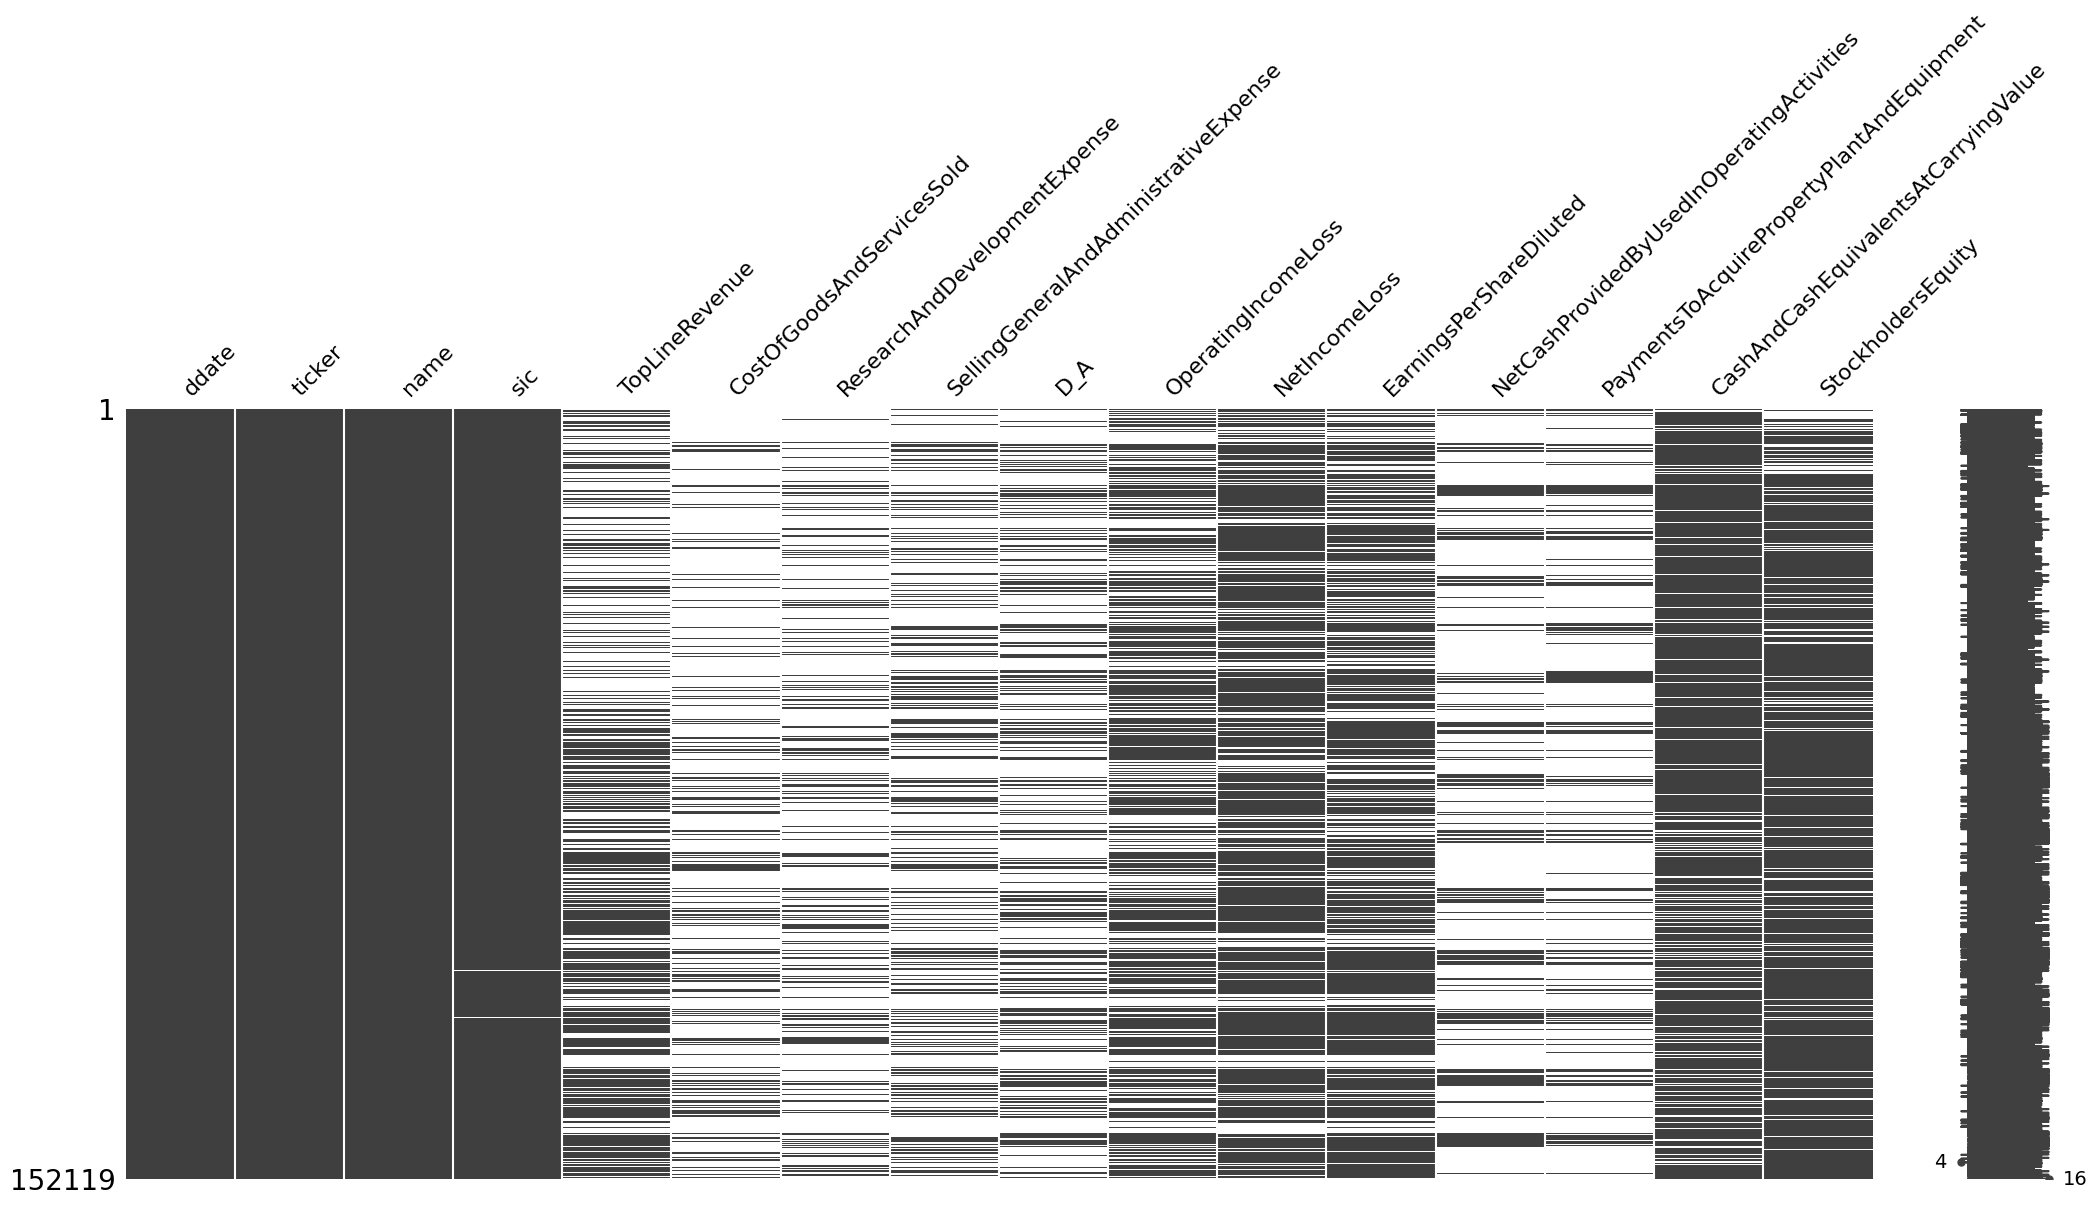

In [41]:
# Create the missingno matrix for master_filtered_8
msno.matrix(master_filtered_8)
plt.show()

In [42]:
# Get the percentage of missing values in each column
pct_missing = master_filtered_8.isnull().mean() * 100
pct_missing

tag
ddate                                          0.000000
ticker                                         0.000000
name                                           0.000000
sic                                            0.422695
TopLineRevenue                                50.494021
CostOfGoodsAndServicesSold                    80.068893
ResearchAndDevelopmentExpense                 77.523518
SellingGeneralAndAdministrativeExpense        70.129964
D_A                                           69.208317
OperatingIncomeLoss                           40.333555
NetIncomeLoss                                 23.219979
EarningsPerShareDiluted                       31.454322
NetCashProvidedByUsedInOperatingActivities    78.479348
PaymentsToAcquirePropertyPlantAndEquipment    81.223253
CashAndCashEquivalentsAtCarryingValue         14.961313
StockholdersEquity                            14.276981
dtype: float64

Clearly there is a lot of missing data still. Let's back into some of these numers using simple arithmetic

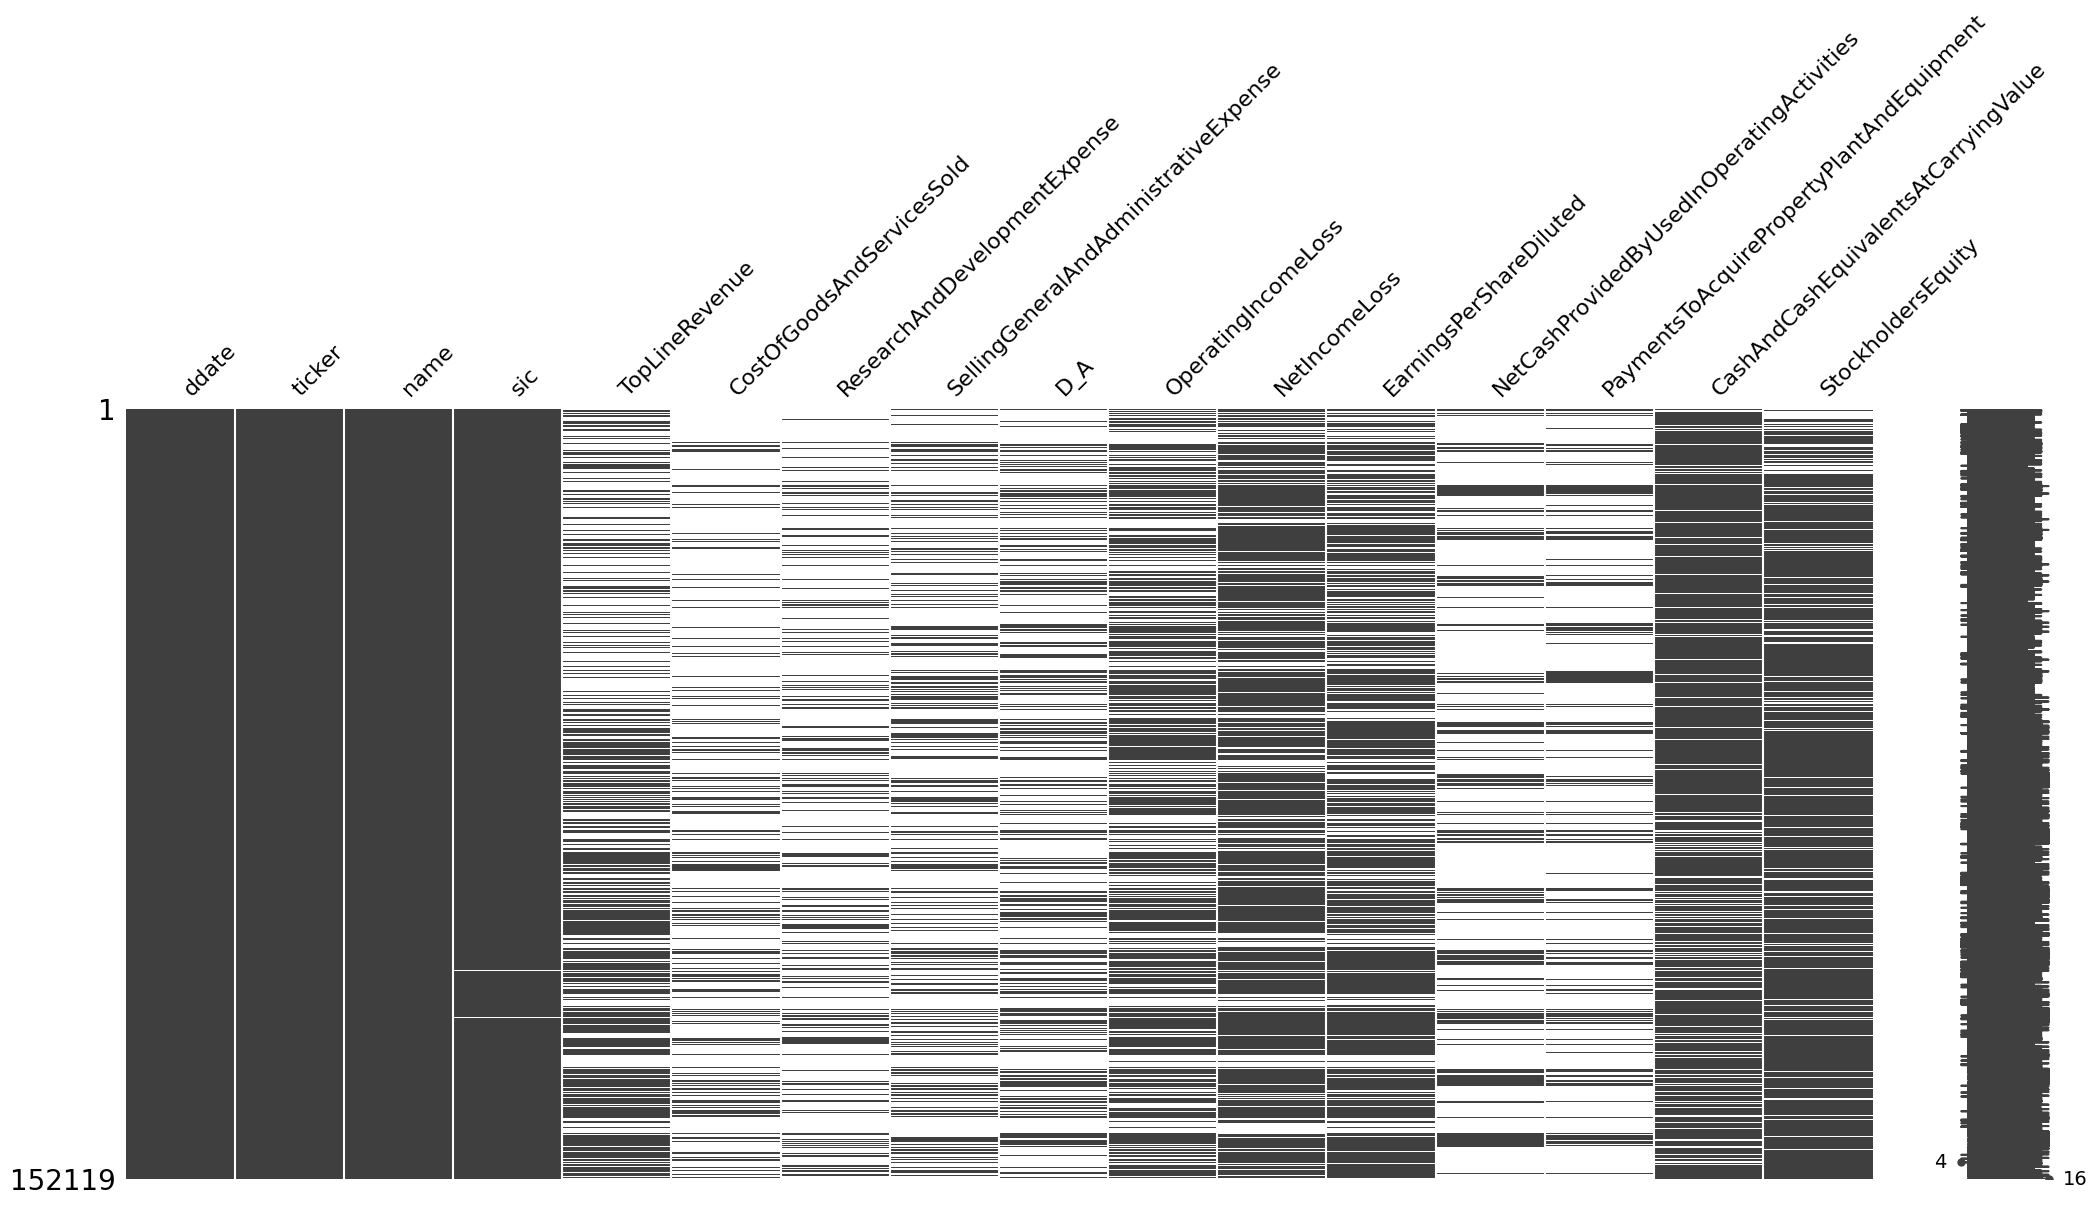

In [43]:
# First calculate OperatingIncomeLoss as TopLineRevenue - CostOfGoodsAndServicesSold - ResearchAndDevelopmentExpense - SellingGeneralAndAdministrativeExpense - DepreciationDepletionAndAmortization
# Where there are no missing values in any of the columns
master_filtered_9 = master_filtered_8.copy()

# Filter rows where there are no missing values in the specified columns
operatingincomeloss_calc = master_filtered_9.dropna(subset=[
    'TopLineRevenue', 
    'CostOfGoodsAndServicesSold', 
    'ResearchAndDevelopmentExpense', 
    'SellingGeneralAndAdministrativeExpense', 
    'D_A'
])

# Calculate OperatingIncomeLoss
master_filtered_9['OperatingIncomeLoss'] = master_filtered_9['OperatingIncomeLoss'].fillna(
    operatingincomeloss_calc['TopLineRevenue'] - 
    operatingincomeloss_calc['CostOfGoodsAndServicesSold'] - 
    operatingincomeloss_calc['ResearchAndDevelopmentExpense'] - 
    operatingincomeloss_calc['SellingGeneralAndAdministrativeExpense'] - 
    operatingincomeloss_calc['D_A']
)

# Show updated missingno matrix
msno.matrix(master_filtered_9)
plt.show()

In [44]:
# Get the percentage of missing values in each column
pct_missing = master_filtered_9.isnull().mean() * 100
pct_missing

tag
ddate                                          0.000000
ticker                                         0.000000
name                                           0.000000
sic                                            0.422695
TopLineRevenue                                50.494021
CostOfGoodsAndServicesSold                    80.068893
ResearchAndDevelopmentExpense                 77.523518
SellingGeneralAndAdministrativeExpense        70.129964
D_A                                           69.208317
OperatingIncomeLoss                           40.254012
NetIncomeLoss                                 23.219979
EarningsPerShareDiluted                       31.454322
NetCashProvidedByUsedInOperatingActivities    78.479348
PaymentsToAcquirePropertyPlantAndEquipment    81.223253
CashAndCashEquivalentsAtCarryingValue         14.961313
StockholdersEquity                            14.276981
dtype: float64

In [45]:
# Create a copy of the DataFrame
master_filtered_10 = master_filtered_9.copy()

# Impute missing values in the 'sic' column with the value that matches the same 'ticker'
master_filtered_10['sic'] = master_filtered_10.groupby('ticker')['sic'].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))

# Get the percentage of missing values in each column
pct_missing = master_filtered_10.isnull().mean() * 100
pct_missing

C:\Users\tjbos\AppData\Local\Temp\ipykernel_17720\439347205.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  master_filtered_10['sic'] = master_filtered_10.groupby('ticker')['sic'].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))


tag
ddate                                          0.000000
ticker                                         0.000000
name                                           0.000000
sic                                            0.352356
TopLineRevenue                                50.494021
CostOfGoodsAndServicesSold                    80.068893
ResearchAndDevelopmentExpense                 77.523518
SellingGeneralAndAdministrativeExpense        70.129964
D_A                                           69.208317
OperatingIncomeLoss                           40.254012
NetIncomeLoss                                 23.219979
EarningsPerShareDiluted                       31.454322
NetCashProvidedByUsedInOperatingActivities    78.479348
PaymentsToAcquirePropertyPlantAndEquipment    81.223253
CashAndCashEquivalentsAtCarryingValue         14.961313
StockholdersEquity                            14.276981
dtype: float64

In [46]:
# Drop rows with missing values in the sic column
master_filtered_10 = master_filtered_10.dropna(subset=['sic'])

# Get the percentage of missing values in each column
pct_missing = master_filtered_10.isnull().mean() * 100
pct_missing

tag
ddate                                          0.000000
ticker                                         0.000000
name                                           0.000000
sic                                            0.000000
TopLineRevenue                                50.324245
CostOfGoodsAndServicesSold                    79.998417
ResearchAndDevelopmentExpense                 77.444041
SellingGeneralAndAdministrativeExpense        70.024343
D_A                                           69.104715
OperatingIncomeLoss                           40.049346
NetIncomeLoss                                 23.144416
EarningsPerShareDiluted                       31.428326
NetCashProvidedByUsedInOperatingActivities    78.476478
PaymentsToAcquirePropertyPlantAndEquipment    81.158837
CashAndCashEquivalentsAtCarryingValue         14.846652
StockholdersEquity                            14.279306
dtype: float64

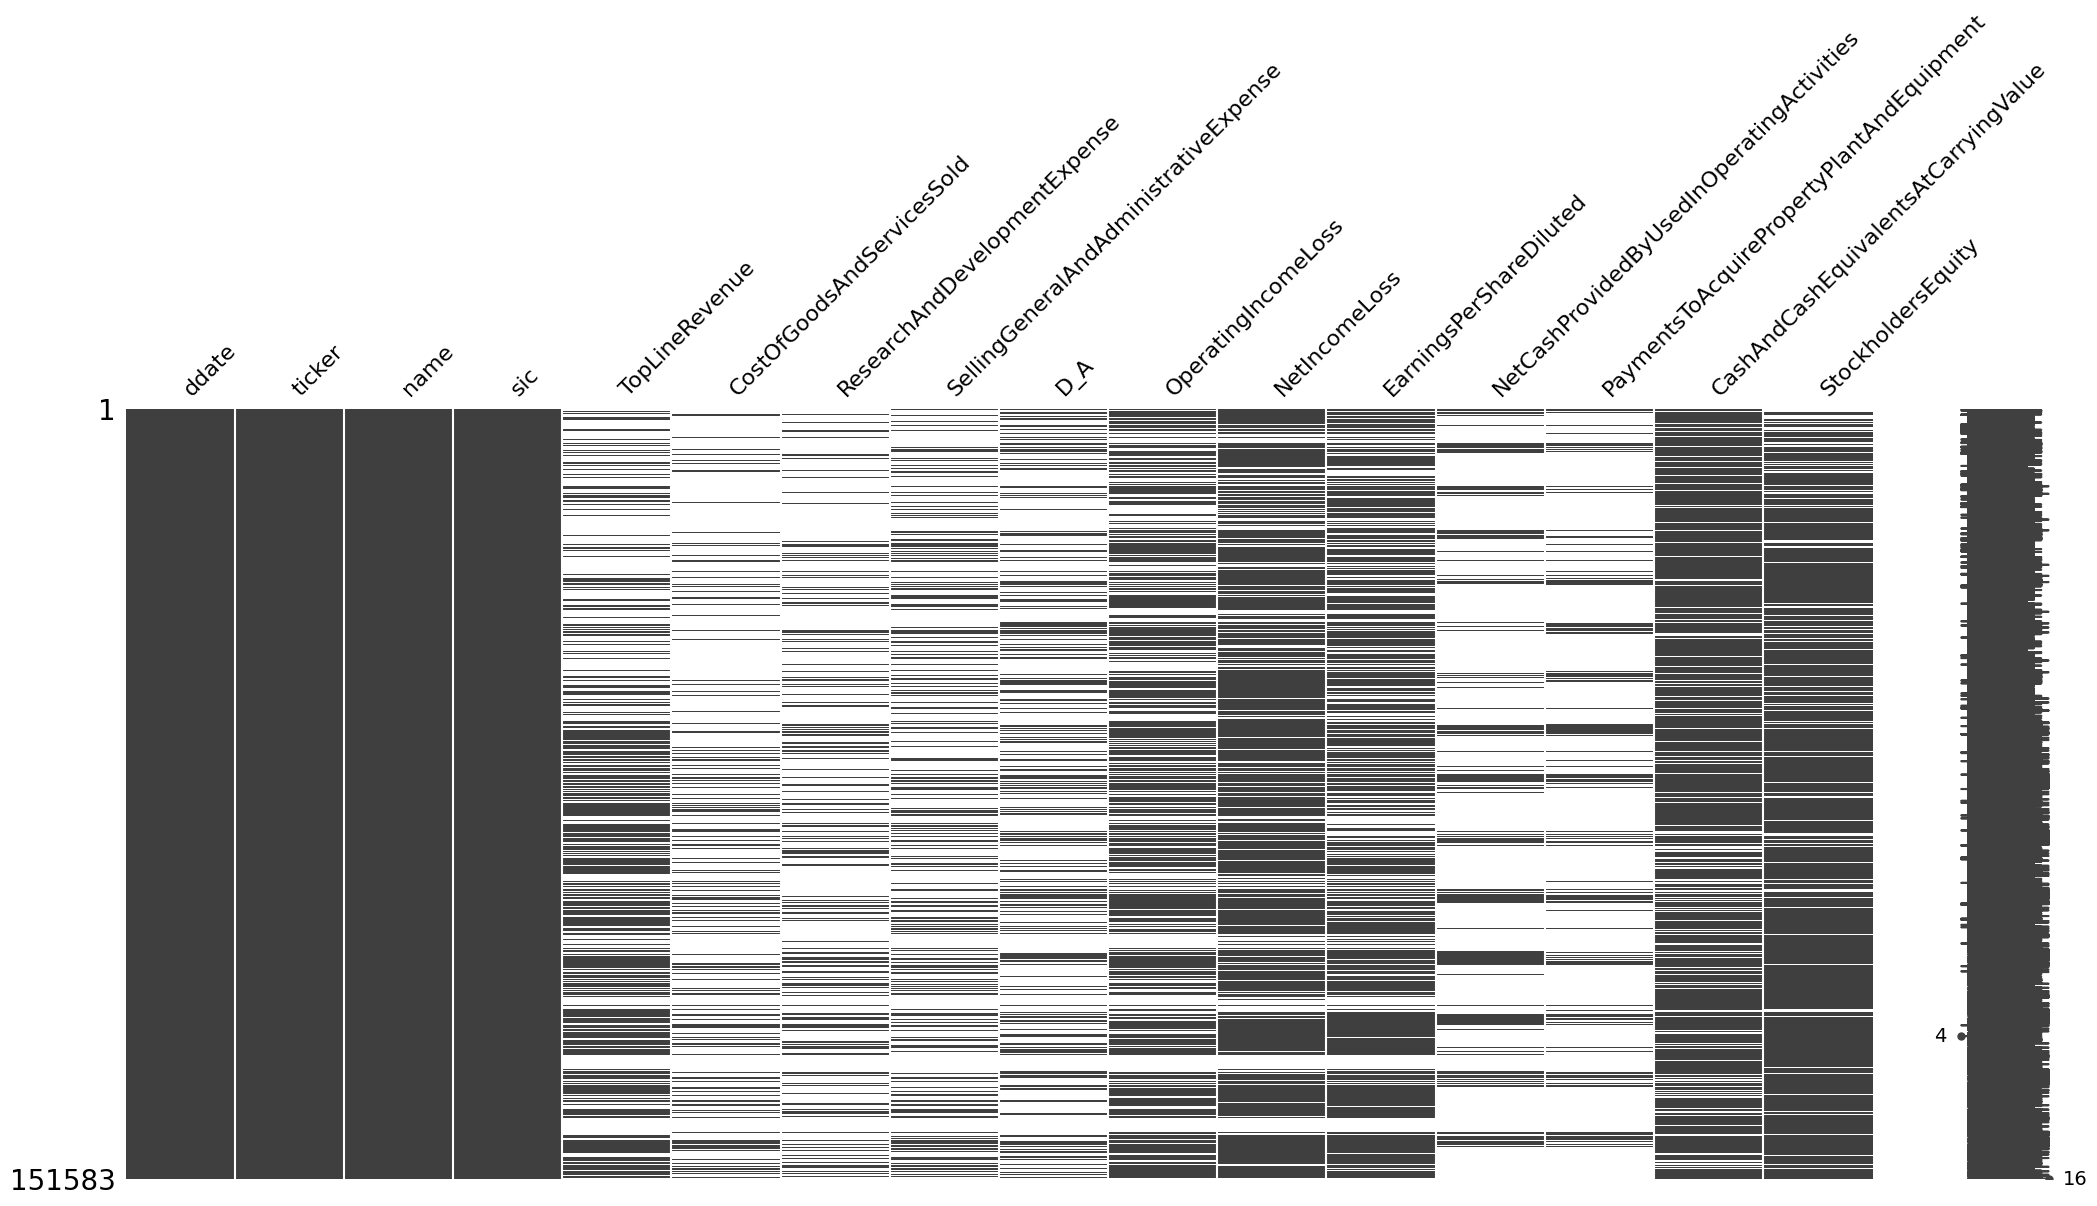

In [47]:
# Plot this missingno matrix just before imputation
msno.matrix(master_filtered_10)
plt.show()

Still couldn't overcome those pesky missing values. Time to impute the best we can...

In [48]:
# Impute the columns that have low amounts of missing data using linear interpolation grouped on ticker
master_imputed = master_filtered_10.copy()
master_imputed['TopLineRevenue'] = master_filtered_10.groupby('ticker')['TopLineRevenue'].transform(lambda x: x.interpolate())
master_imputed['OperatingIncomeLoss'] = master_filtered_10.groupby('ticker')['OperatingIncomeLoss'].transform(lambda x: x.interpolate())
master_imputed['NetIncomeLoss'] = master_filtered_10.groupby('ticker')['NetIncomeLoss'].transform(lambda x: x.interpolate())
master_imputed['EarningsPerShareDiluted'] = master_filtered_10.groupby('ticker')['EarningsPerShareDiluted'].transform(lambda x: x.interpolate())
master_imputed['CashAndCashEquivalentsAtCarryingValue'] = master_filtered_10.groupby('ticker')['CashAndCashEquivalentsAtCarryingValue'].transform(lambda x: x.interpolate())
master_imputed['StockholdersEquity'] = master_filtered_10.groupby('ticker')['StockholdersEquity'].transform(lambda x: x.interpolate())

# Get the percentage of missing values in each column
pct_missing = master_imputed.isnull().mean() * 100
pct_missing

tag
ddate                                          0.000000
ticker                                         0.000000
name                                           0.000000
sic                                            0.000000
TopLineRevenue                                36.713220
CostOfGoodsAndServicesSold                    79.998417
ResearchAndDevelopmentExpense                 77.444041
SellingGeneralAndAdministrativeExpense        70.024343
D_A                                           69.104715
OperatingIncomeLoss                           23.608848
NetIncomeLoss                                  5.839705
EarningsPerShareDiluted                       14.534611
NetCashProvidedByUsedInOperatingActivities    78.476478
PaymentsToAcquirePropertyPlantAndEquipment    81.158837
CashAndCashEquivalentsAtCarryingValue          5.408918
StockholdersEquity                             5.554713
dtype: float64

In [49]:
# Drop high missing value columns
master_imputed_dropped = master_imputed.copy()
master_imputed_dropped.drop(columns=['CostOfGoodsAndServicesSold',
                                    'ResearchAndDevelopmentExpense',
                                    'SellingGeneralAndAdministrativeExpense',
                                    'D_A',
                                    'PaymentsToAcquirePropertyPlantAndEquipment', 
                                    'NetCashProvidedByUsedInOperatingActivities'], inplace=True)

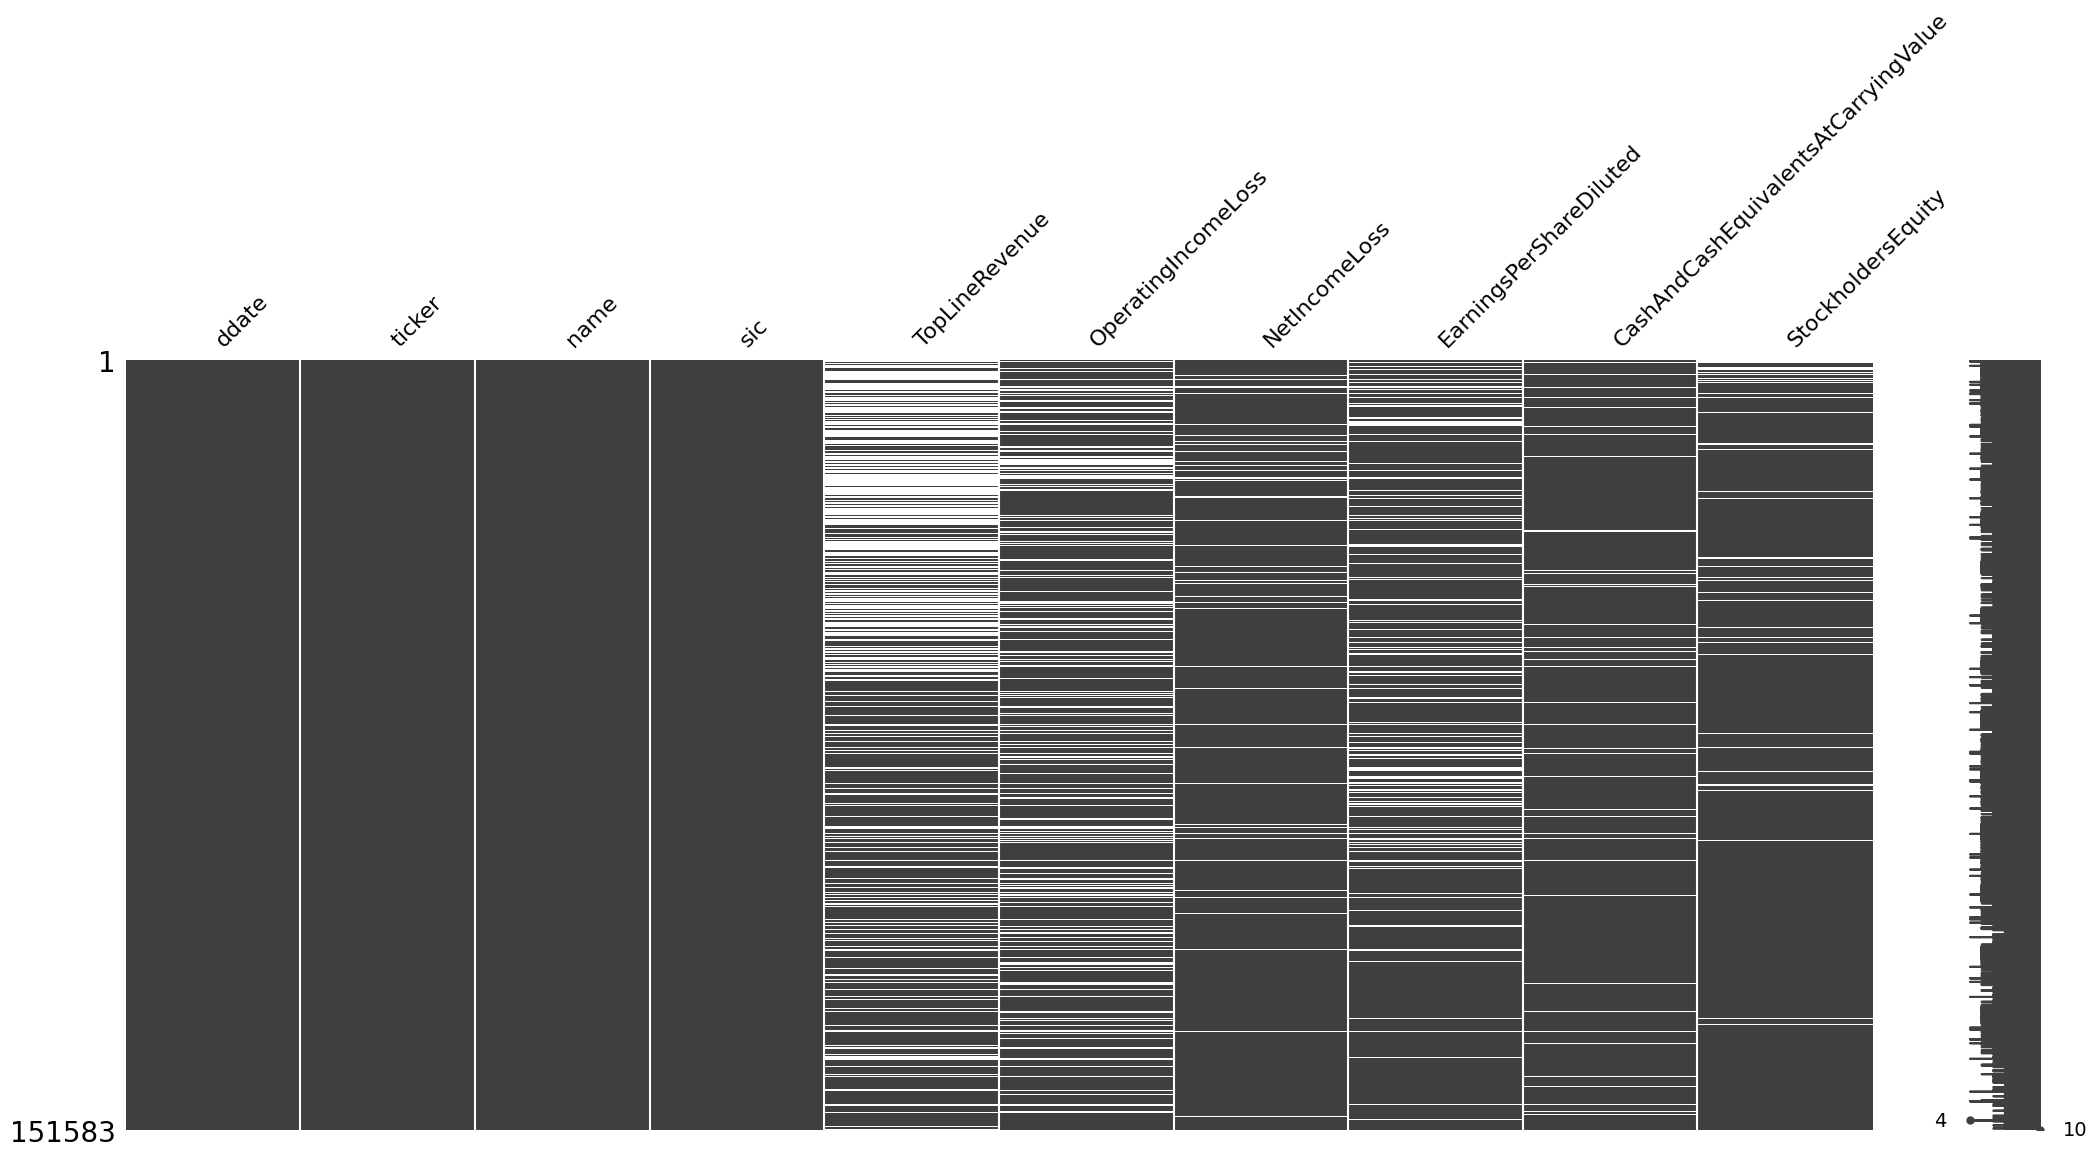

In [50]:
# Show the new missingno matrix for master_imputed_dropped
msno.matrix(master_imputed_dropped)
plt.show()

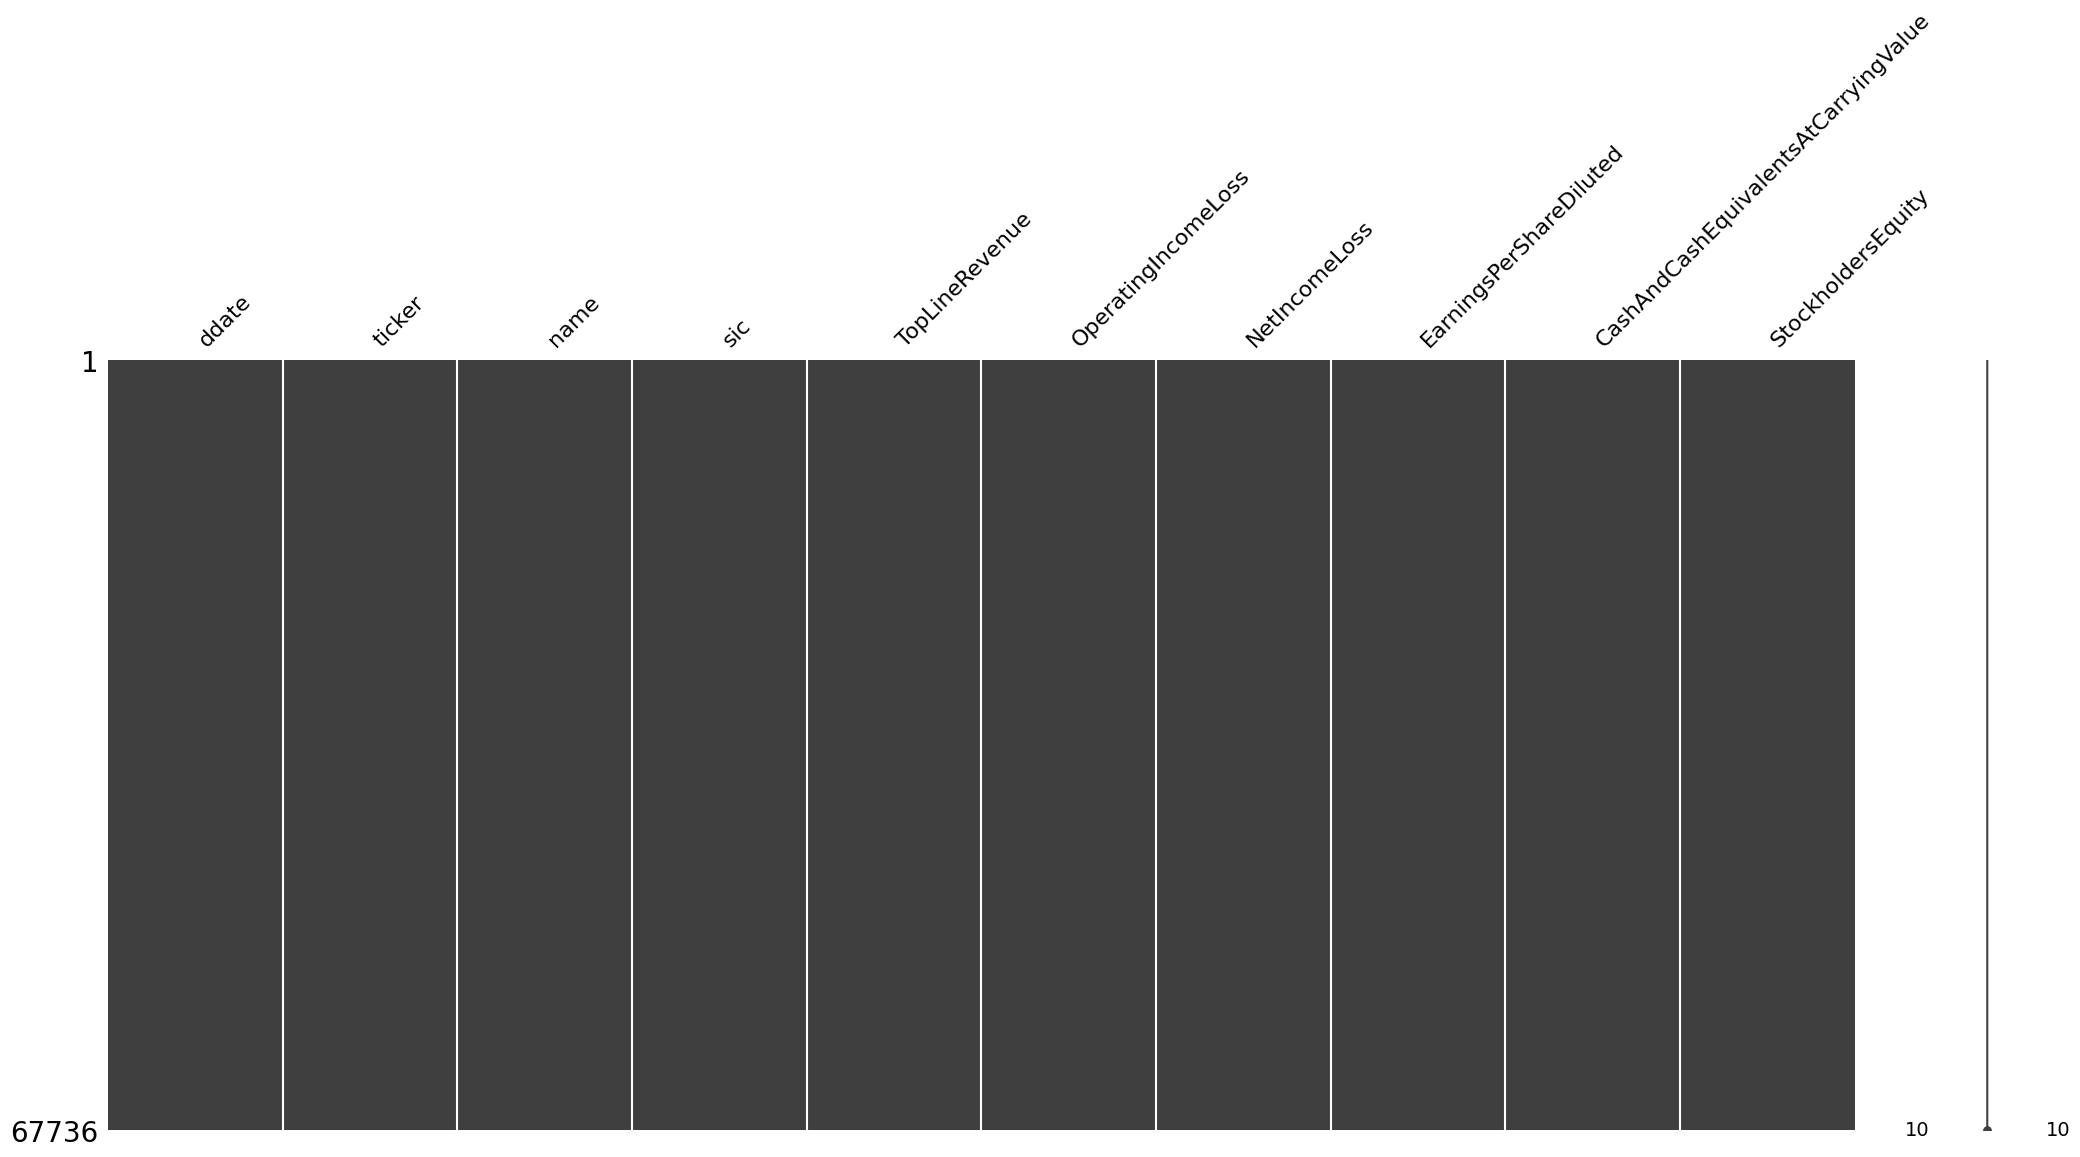

In [51]:
# Test dropping any row with na
test_drop = master_imputed_dropped.copy()
test_drop.dropna(inplace=True)
msno.matrix(test_drop)
plt.show()

We still have 67736 rows to work with... How many unique tickers are left?

In [52]:
# Get the number of unique tickers
test_drop['ticker'].nunique()

# 2421 is still a good sample size, and 2421 / 67736 means there is still a bit of data for each stock

2421

In [53]:
# Find the stocks that have the least data points in the set
ticker_counts = test_drop['ticker'].value_counts()
ticker_counts.sort_values(ascending = True)

ticker
FERG     1
PRLD     1
ATNM     1
ADN      2
GRAL     2
        ..
SXC     75
AM      75
OGE     78
ARCT    82
BHE     83
Name: count, Length: 2421, dtype: int64

In [54]:
# Remove lines where ticker < 20
master_imputed_dropped_filtered = test_drop[test_drop['ticker'].isin(ticker_counts[ticker_counts > 30].index)]
print(master_imputed_dropped_filtered['ticker'].nunique())
print(len(master_imputed_dropped_filtered))
print(master_imputed_dropped_filtered['ddate'].nunique())

1011
43563
179


Well, after running this exercise for all stocks no mkt cap limit it seems there is a bigger sample size here that might be better for modeling on

In [55]:
master_filtered_10['ddate'].nunique()

179

In [56]:
#fl_test_df = master_filtered_6[master_filtered_10['ticker'] == 'FL']
#fl_test_df.head(20)

Using the list of unique_tickers, get monthly historical data for each stock.

The final data frame will have 3 columns, 'date', 'ticker', and 'price'

In [57]:
import yfinance as yf

# Define a function to scrape yahoo finance for the monthly historical pricing data between 1/1/2010 and 12/31/2024
def get_historical_prices(ticker):
    try:
        # Get the historical data for the specified ticker
        historical_data = yf.Ticker(ticker).history(start='2010-01-01', end='2025-01-02', interval = '1mo')
        
        # Reset the index of the DataFrame
        historical_data.reset_index(inplace=True)
        
        # Return the historical data
        return historical_data
    except:
        # If an error occurs, return None
        return f"Error fetching data for ticker {ticker}"

In [58]:
get_historical_prices('AAPL')

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-01-01 00:00:00-05:00,6.422876,6.487879,5.725307,5.779776,15168994400,0.00,0.0
1,2010-02-01 00:00:00-05:00,5.789106,6.174304,5.743363,6.157753,10776080000,0.00,0.0
2,2010-03-01 00:00:00-05:00,6.191759,7.146629,6.182731,7.071996,12154172800,0.00,0.0
3,2010-04-01 00:00:00-04:00,7.144523,8.199303,7.004287,7.857140,12367129600,0.00,0.0
4,2010-05-01 00:00:00-04:00,7.939895,8.061474,5.996150,7.730444,18082654800,0.00,0.0
...,...,...,...,...,...,...,...,...
176,2024-09-01 00:00:00-04:00,228.048102,232.578126,213.450225,232.488327,1232140300,0.00,0.0
177,2024-10-01 00:00:00-04:00,229.015968,236.968466,220.843951,225.413895,930736000,0.00,0.0
178,2024-11-01 00:00:00-04:00,220.484749,237.287764,219.227521,236.808823,891640600,0.25,0.0
179,2024-12-01 00:00:00-05:00,237.009422,259.814351,236.899542,250.144974,977916100,0.00,0.0


In [ ]:
# RUN ONE TIME THEN COMMENT OUT
# Create a loop that iterates through the unique tickers and fetches the historical data
#historical_data = pd.DataFrame()

#i = 0

# master_imputed_dropped_filtered['ticker'].unique()

#for ticker in master_imputed_dropped_filtered['ticker'].unique():
#    i+=1
#
#    data = get_historical_prices(ticker)
#    data.to_parquet(f'../data/raw/price_batches/{ticker}.parquet')
#
#    print(f'Iteration #{i}: Fetched data for {ticker}')

In [ ]:
# Read all individual pricing parquet files into a single DataFrame
master_price_data = pd.DataFrame()

for ticker in master_imputed_dropped_filtered['ticker'].unique():
    data = pd.read_parquet(f'../data/raw/price_batches/{ticker}.parquet')
    data['ticker'] = ticker
    master_price_data = pd.concat([master_price_data, data], ignore_index=True)

In [61]:
master_price_data.head(5)

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,ticker
0,2010-01-01 00:00:00-05:00,42.135614,43.069109,40.439642,40.924206,61205800,0.000,0.0,COST
1,2010-02-01 00:00:00-05:00,41.187853,43.838699,40.874314,43.446774,72957800,0.180,0.0,COST
2,2010-03-01 00:00:00-05:00,43.601723,44.402279,42.629619,42.679653,78643100,0.000,0.0,COST
3,2010-04-01 00:00:00-04:00,42.693946,44.287911,41.893391,42.229340,83104700,0.000,0.0,COST
4,2010-05-01 00:00:00-04:00,42.193607,43.480218,39.313035,41.636078,118287900,0.205,0.0,COST


In [62]:
# Shift the month column back by one month to align with the fundamental data
# Right now this is the first of the month, the other is the last day of the month. When they are both in yyyymm format, they will align

#master_price_data['date'] = pd.to_datetime(master_price_data['date'], format='%Y%m') - pd.offsets.MonthBegin(1)
#master_price_data['date'] = master_price_data['date'].dt.strftime('%Y%m')

In [63]:
len(master_price_data)

165607

Now that we have all the pricing data there are two ways forward. 

We can 1. join the pricing data with the fundamental data causing interval gaps for certain tickers with poor reporting 

or 2. join the fundamental data with the pricing data and impute missing fundamental data for tickers that have gaps.

In [81]:
# Starting with approach 2 to see how many missing values there will end up being
# Start by formatting ddate correctly
master_fundamental_prejoin = master_imputed_dropped_filtered.copy()
master_fundamental_prejoin['ddate'] = pd.to_datetime(master_fundamental_prejoin['ddate'], format='%Y%m%d')
master_fundamental_prejoin['ddate'] = master_fundamental_prejoin['ddate'].dt.strftime('%Y%m')

master_fundamental_prejoin.head(5)

tag,ddate,ticker,name,sic,TopLineRevenue,OperatingIncomeLoss,NetIncomeLoss,EarningsPerShareDiluted,CashAndCashEquivalentsAtCarryingValue,StockholdersEquity
7300,201001,COST,COSTCO WHOLESALE CORP /NEW,5331.0,1.874200e+10,4.700000e+08,2.990000e+08,0.67,4.134000e+09,1.065100e+10
7303,201001,CRM,SALESFORCE COM INC,7372.0,3.540490e+08,2.551900e+07,2.039400e+07,0.16,1.011306e+09,1.043802e+09
7327,201001,HPQ,HEWLETT PACKARD CO,3570.0,3.117700e+10,3.003000e+09,2.250000e+09,0.93,1.354700e+10,4.162800e+10
7328,201001,HRB,H&R BLOCK INC,7200.0,9.348520e+08,9.444400e+07,5.063500e+07,0.15,1.727677e+09,9.364670e+08
7395,201002,ADBE,ADOBE SYSTEMS INC,7372.0,8.587000e+08,1.768330e+08,1.271540e+08,0.24,1.589442e+09,5.171420e+09


In [82]:
print(master_fundamental_prejoin.columns)
print(master_price_data.columns)

Index(['ddate', 'ticker', 'name', 'sic', 'TopLineRevenue',
       'OperatingIncomeLoss', 'NetIncomeLoss', 'EarningsPerShareDiluted',
       'CashAndCashEquivalentsAtCarryingValue', 'StockholdersEquity'],
      dtype='object', name='tag')
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits', 'ticker'],
      dtype='object')


In [ ]:
# Join fundamental data with pricing data on ticker and date
# Convert 'Date' column in master_price_data to datetime
#master_price_data['Date'] = pd.to_datetime(master_price_data['Date'], format='%Y-%m')

# Format 'Date' column to match the 'ddate' format in master_fundamental_prejoin
#master_price_data['Date'] = master_price_data['Date'].dt.strftime('%Y%m')

master_joined_v2 = master_price_data.merge(master_fundamental_prejoin, left_on=['ticker', 'Date'], right_on=['ticker', 'ddate'], how='left')
# If you get an error running this code, try uncommenting the above datetime conversions in this cell

In [ ]:
master_joined_v2.head(5)

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,ticker,date,ddate,name,sic,TopLineRevenue,OperatingIncomeLoss,NetIncomeLoss,EarningsPerShareDiluted,CashAndCashEquivalentsAtCarryingValue,StockholdersEquity
0,2010-01-01 00:00:00-05:00,42.135614,43.069109,40.439642,40.924206,61205800,0.000,0.0,COST,200912,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-02-01 00:00:00-05:00,41.187853,43.838699,40.874314,43.446774,72957800,0.180,0.0,COST,201001,201001,COSTCO WHOLESALE CORP /NEW,5331.0,1.874200e+10,470000000.0,299000000.0,0.67,4.134000e+09,1.065100e+10
2,2010-03-01 00:00:00-05:00,43.601723,44.402279,42.629619,42.679653,78643100,0.000,0.0,COST,201002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-04-01 00:00:00-04:00,42.693946,44.287911,41.893391,42.229340,83104700,0.000,0.0,COST,201003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-05-01 00:00:00-04:00,42.193607,43.480218,39.313035,41.636078,118287900,0.205,0.0,COST,201004,201004,COSTCO WHOLESALE CORP /NEW,5331.0,1.778000e+10,491000000.0,306000000.0,0.68,4.413000e+09,1.087400e+10


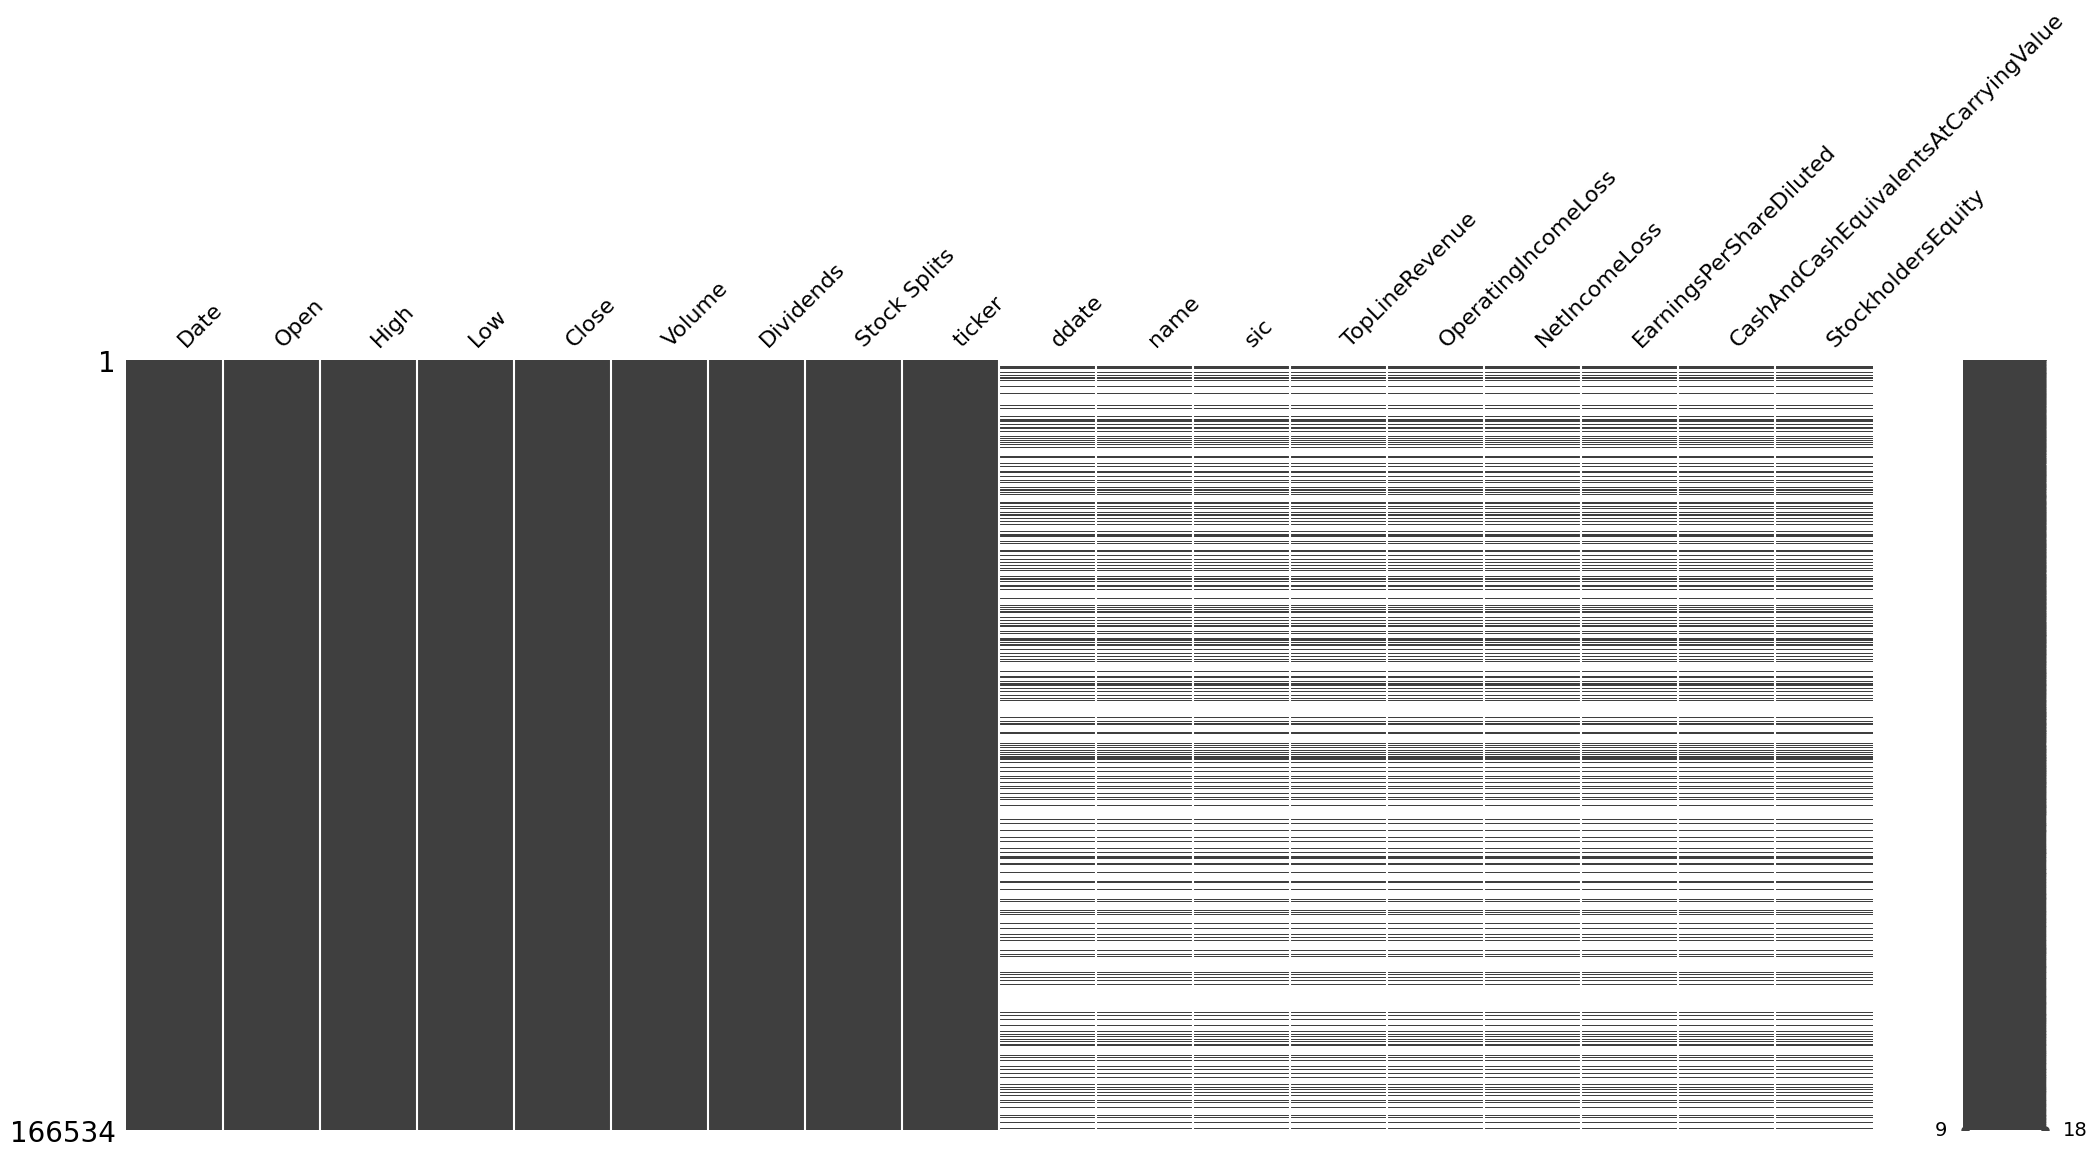

Date                                      0.000000
Open                                      0.000000
High                                      0.000000
Low                                       0.000000
Close                                     0.000000
Volume                                    0.000000
Dividends                                 0.000000
Stock Splits                              0.000000
ticker                                    0.000000
ddate                                    74.972078
name                                     74.972078
sic                                      74.972078
TopLineRevenue                           74.972078
OperatingIncomeLoss                      74.972078
NetIncomeLoss                            74.972078
EarningsPerShareDiluted                  74.972078
CashAndCashEquivalentsAtCarryingValue    74.972078
StockholdersEquity                       74.972078
dtype: float64

In [87]:
# Create a missing map of master_joined
msno.matrix(master_joined_v2)
plt.show()

# Get the percentage of missing values in each column
pct_missing = master_joined_v2.isnull().mean() * 100
pct_missing

In [ ]:
# Looks like Approach 2 isn't viable. Let's do approach 1 instead

In [89]:
master_joined = master_fundamental_prejoin.merge(master_price_data, left_on=['ticker', 'ddate'], right_on=['ticker', 'Date'], how='left')

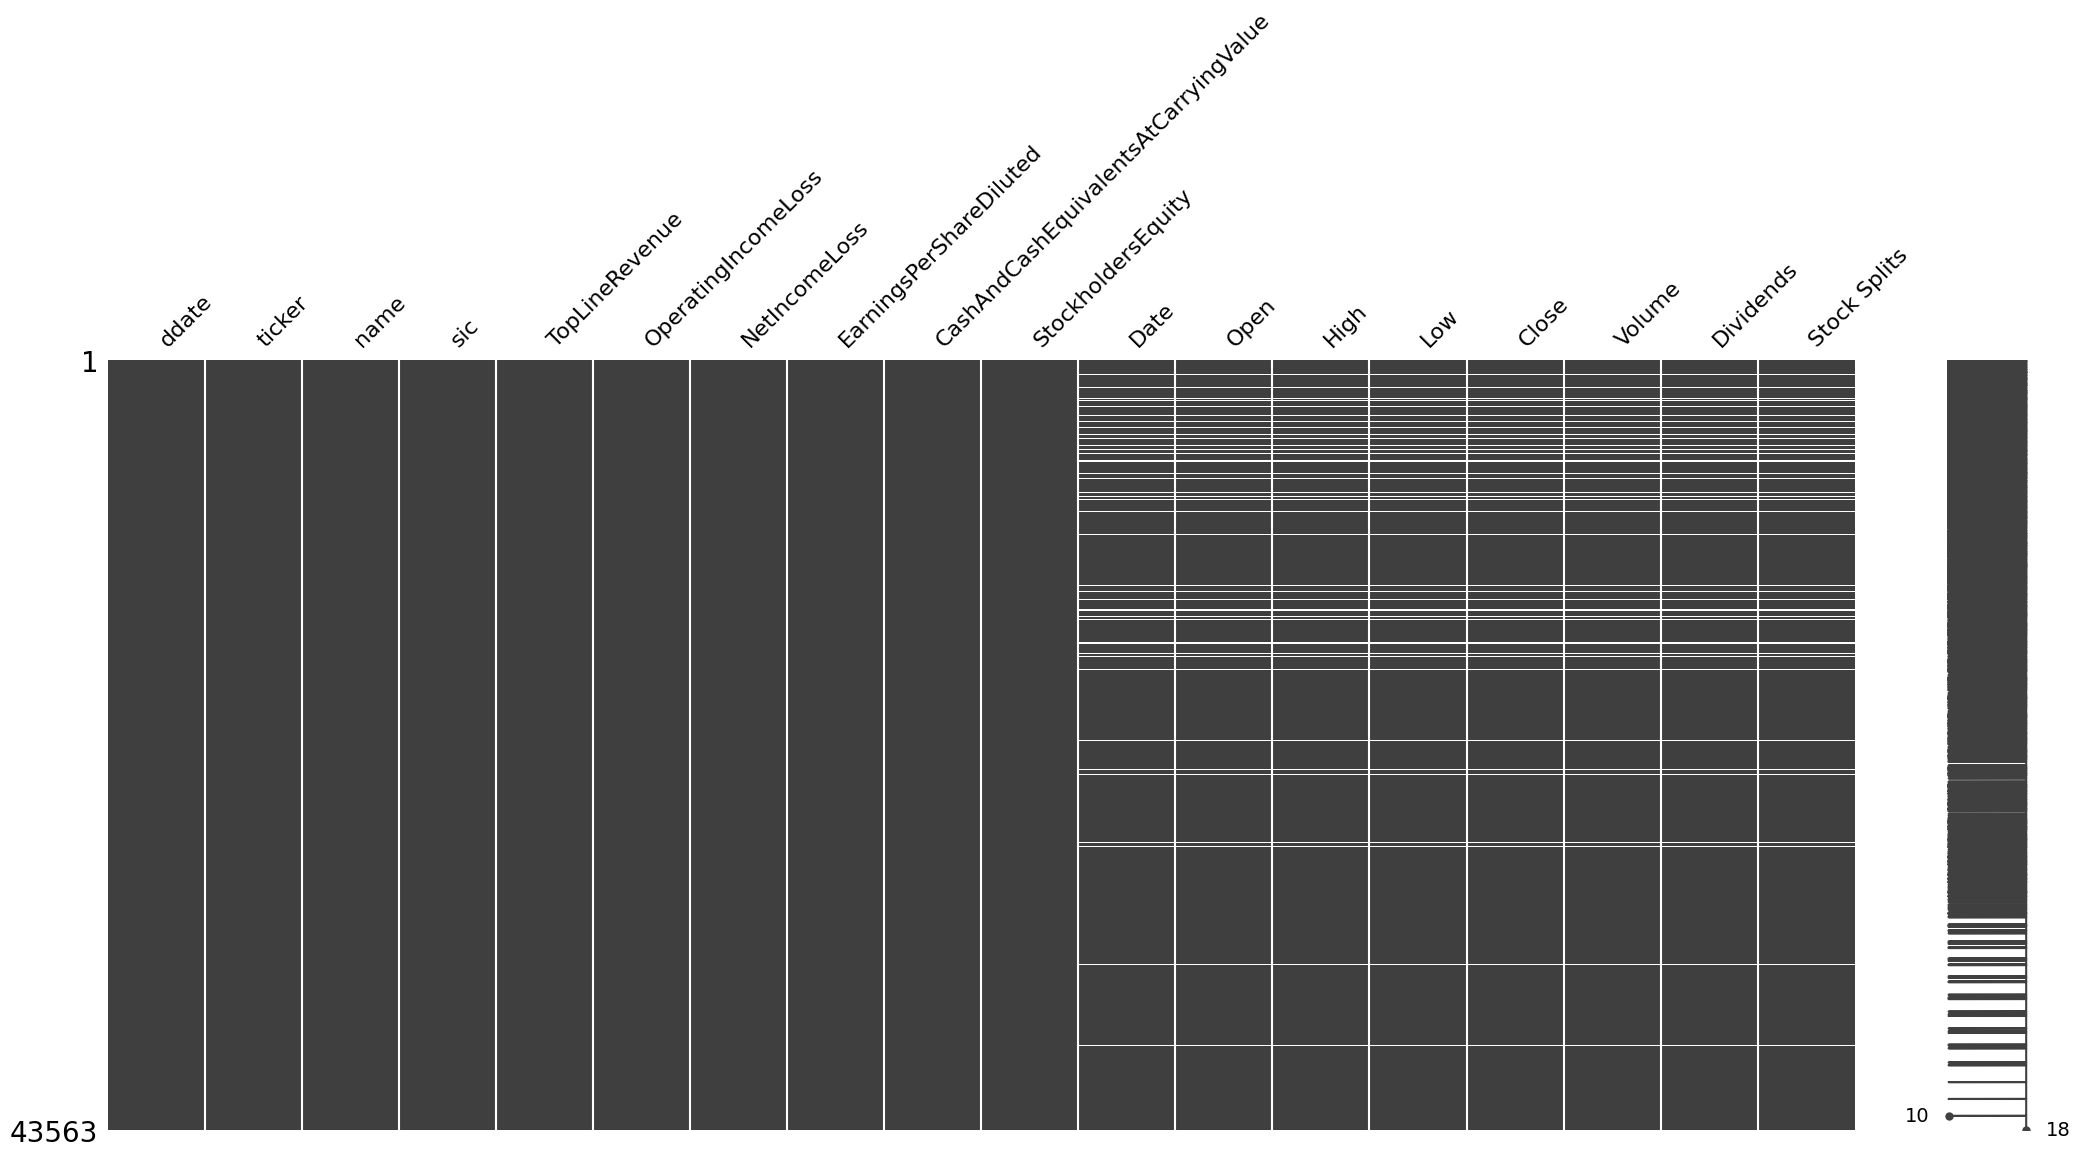

ddate                                    0.000000
ticker                                   0.000000
name                                     0.000000
sic                                      0.000000
TopLineRevenue                           0.000000
OperatingIncomeLoss                      0.000000
NetIncomeLoss                            0.000000
EarningsPerShareDiluted                  0.000000
CashAndCashEquivalentsAtCarryingValue    0.000000
StockholdersEquity                       0.000000
Date                                     4.322475
Open                                     4.322475
High                                     4.322475
Low                                      4.322475
Close                                    4.322475
Volume                                   4.322475
Dividends                                4.322475
Stock Splits                             4.322475
dtype: float64

In [90]:
# Create a missing map of master_joined
msno.matrix(master_joined)
plt.show()

# Get the percentage of missing values in each column
pct_missing = master_joined.isnull().mean() * 100
pct_missing

In [91]:
# Remove rows with missing values
master_joined_dropped = master_joined.copy()

master_joined_dropped.dropna(inplace=True)
len(master_joined_dropped)

41680

In [92]:
master_joined_dropped.head(5)

,ddate,ticker,name,sic,TopLineRevenue,OperatingIncomeLoss,NetIncomeLoss,EarningsPerShareDiluted,CashAndCashEquivalentsAtCarryingValue,StockholdersEquity,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,201001,COST,COSTCO WHOLESALE CORP /NEW,5331.0,1.874200e+10,4.700000e+08,2.990000e+08,0.67,4.134000e+09,1.065100e+10,201001,42.135614,43.069109,40.439642,40.924206,61205800.0,0.0,0.0
1,201001,CRM,SALESFORCE COM INC,7372.0,3.540490e+08,2.551900e+07,2.039400e+07,0.16,1.011306e+09,1.043802e+09,201001,18.548897,18.777619,15.712241,15.799254,167783200.0,0.0,0.0
2,201001,HPQ,HEWLETT PACKARD CO,3570.0,3.117700e+10,3.003000e+09,2.250000e+09,0.93,1.354700e+10,4.162800e+10,201001,15.595603,16.019232,14.161316,14.243016,623195068.0,0.0,0.0
3,201001,HRB,H&R BLOCK INC,7200.0,9.348520e+08,9.444400e+07,5.063500e+07,0.15,1.727677e+09,9.364670e+08,201001,12.910437,13.217692,12.176436,12.244716,68982900.0,0.0,0.0
4,201002,ADBE,ADOBE SYSTEMS INC,7372.0,8.587000e+08,1.768330e+08,1.271540e+08,0.24,1.589442e+09,5.171420e+09,201002,32.389999,34.700001,31.280001,34.650002,176471300.0,0.0,0.0


In [ ]:
# Drop unnecessary columns
master_joined_dropped = master_joined_dropped.drop(columns=['Date', 'Open','High','Low','date'])

In [ ]:
master_joined_dropped['Stock Splits'].value_counts()

Stock Splits
0.000000     41643
0.100000        14
2.000000        12
3.000000         6
4.000000         3
0.050000         3
0.200000         3
0.083333         3
1.216000         2
1.385000         2
0.250000         2
1.300000         2
10.000000        2
0.166667         2
0.333333         2
5.000000         2
20.000000        1
1.896000         1
1.175000         1
1.973000         1
1.963000         1
1.025000         1
1.164000         1
0.013333         1
1.019000         1
1.136000         1
1.010000         1
0.066667         1
1.128000         1
1.065000         1
1.622000         1
1.196000         1
0.125000         1
0.062500         1
3.502000         1
1.388000         1
1.012000         1
0.377500         1
1.087000         1
1.226693         1
1.183000         1
1.002746         1
1.398000         1
1.655000         1
7.000000         1
2.202000         1
0.487329         1
1.194000         1
1.666667         1
1.237000         1
0.031000         1
1.030000         1

In [ ]:
# Rename Close to CurrentPrice and ddate to CurrentPeriodDate
master_joined_dropped.rename(columns={'Close': 'CurrentPrice', 'CurrentPeriod': 'CurrentPeriodDate'}, inplace=True)

# Verify that the columns have been renamed correctly
print(master_joined_dropped.columns)

# Create a column called FuturePeriodPrice that is the price of the next month grouped by ticker
master_joined_dropped['FuturePeriodPrice'] = master_joined_dropped.groupby('ticker')['CurrentPrice'].shift(-1)
master_joined_dropped['FuturePeriodDate'] = master_joined_dropped.groupby('ticker')['CurrentPeriodDate'].shift(-1)

# Convert CurrentPeriodDate and FuturePeriodDate to integers
master_joined_dropped['CurrentPeriodDate'] = master_joined_dropped['CurrentPeriodDate'].astype(int)
master_joined_dropped['FuturePeriodDate'] = master_joined_dropped['FuturePeriodDate'].astype(int)

# Calculate the period length in months
master_joined_dropped['PeriodLength'] = (
    (master_joined_dropped['FuturePeriodDate'] // 100 - master_joined_dropped['CurrentPeriodDate'] // 100) * 12 +
    (master_joined_dropped['FuturePeriodDate'] % 100 - master_joined_dropped['CurrentPeriodDate'] % 100)
)

# Create a column called PeriodPctReturn that is the percentage change between CurrentPrice and FuturePeriodPrice
master_joined_dropped['PeriodPctReturn'] = (
    (master_joined_dropped['FuturePeriodPrice'] - master_joined_dropped['CurrentPrice']) / 
    master_joined_dropped['CurrentPrice']
)

# Create a column called PriceDirection
# Strong Buy: PeriodPctReturn > 0.05
# Buy: 0.05 >= PeriodPctReturn > 0.02
# Hold: 0.02 >= PeriodPctReturn > -0.02
# Sell: -0.02 >= PeriodPctReturn > -0.05
# Strong Sell: PeriodPctReturn <= -0.05
# Call each of the above 2, 1, 0, -1, -2
master_joined_dropped['PriceDirection'] = master_joined_dropped['PeriodPctReturn'].apply(
    lambda x: 2 if x > 0.05 else 1 if x > 0.02 else 0 if x > -0.02 else -1 if x > -0.05 else -2
)

# Display the first few rows of the DataFrame
master_joined_dropped.head(5)

Index(['CurrentPeriodDate', 'ticker', 'name', 'sic', 'TopLineRevenue',
       'OperatingIncomeLoss', 'NetIncomeLoss', 'EarningsPerShareDiluted',
       'CashAndCashEquivalentsAtCarryingValue', 'StockholdersEquity',
       'CurrentPrice', 'Volume', 'Dividends', 'Stock Splits',
       'FuturePeriodPrice', 'PeriodPctReturn', 'PriceDirection',
       'FuturePeriodDate'],
      dtype='object')


IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [ ]:
# Rename Close to CurrentPrice and ddate to CurrentPeriodDate
master_joined_dropped.rename(columns={'Close': 'CurrentPrice', 'ddate': 'CurrentPeriodDate'}, inplace=True)

# Verify that the columns have been renamed correctly
print(master_joined_dropped.columns)

# Create a column called FuturePeriodPrice that is the price of the next month grouped by ticker
master_joined_dropped['FuturePeriodPrice'] = master_joined_dropped.groupby('ticker')['CurrentPrice'].shift(-1)
master_joined_dropped['FuturePeriodDate'] = master_joined_dropped.groupby('ticker')['CurrentPeriodDate'].shift(-1)

# Fill NaN values with a placeholder (e.g., 0)
master_joined_dropped['CurrentPeriodDate'].fillna(0, inplace=True)
master_joined_dropped['FuturePeriodDate'].fillna(0, inplace=True)

# Convert CurrentPeriodDate and FuturePeriodDate to integers
master_joined_dropped['CurrentPeriodDate'] = master_joined_dropped['CurrentPeriodDate'].astype(int)
master_joined_dropped['FuturePeriodDate'] = master_joined_dropped['FuturePeriodDate'].astype(int)

# Calculate the period length in months
master_joined_dropped['PeriodLength'] = (
    (master_joined_dropped['FuturePeriodDate'] // 100 - master_joined_dropped['CurrentPeriodDate'] // 100) * 12 +
    (master_joined_dropped['FuturePeriodDate'] % 100 - master_joined_dropped['CurrentPeriodDate'] % 100)
)

# Handle the placeholder values appropriately (e.g., set PeriodLength to NaN where FuturePeriodDate was originally NaN)
master_joined_dropped.loc[master_joined_dropped['FuturePeriodDate'] == 0, 'PeriodLength'] = np.nan

# Create a column called PeriodPctReturn that is the percentage change between CurrentPrice and FuturePeriodPrice
master_joined_dropped['PeriodPctReturn'] = (
    (master_joined_dropped['FuturePeriodPrice'] - master_joined_dropped['CurrentPrice']) / 
    master_joined_dropped['CurrentPrice']
)

# Display the first few rows of the DataFrame
master_joined_dropped.tail(5)

Index(['CurrentPeriodDate', 'ticker', 'name', 'sic', 'TopLineRevenue',
       'OperatingIncomeLoss', 'NetIncomeLoss', 'EarningsPerShareDiluted',
       'CashAndCashEquivalentsAtCarryingValue', 'StockholdersEquity',
       'CurrentPrice', 'Volume', 'Dividends', 'Stock Splits',
       'FuturePeriodPrice', 'PeriodPctReturn', 'PriceDirection',
       'FuturePeriodDate', 'PeriodLength'],
      dtype='object')


C:\Users\tjbos\AppData\Local\Temp\ipykernel_30072\312259533.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  master_joined_dropped['CurrentPeriodDate'].fillna(0, inplace=True)
C:\Users\tjbos\AppData\Local\Temp\ipykernel_30072\312259533.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

,CurrentPeriodDate,ticker,name,sic,TopLineRevenue,OperatingIncomeLoss,NetIncomeLoss,EarningsPerShareDiluted,CashAndCashEquivalentsAtCarryingValue,StockholdersEquity,CurrentPrice,Volume,Dividends,Stock Splits,FuturePeriodPrice,PeriodPctReturn,PriceDirection,FuturePeriodDate,PeriodLength
43558,202411,MU,MICRON TECHNOLOGY INC,3674.0,8.709000e+09,2.174000e+09,1.870000e+09,1.67,6.693000e+09,4.679700e+10,84.050804,574561300.0,0.115,0.0,NaN,NaN,-2,0,NaN
43559,202411,ORCL,ORACLE CORP,7372.0,1.405900e+10,4.220000e+09,3.151000e+09,1.10,1.094100e+10,1.374600e+10,166.231415,196442000.0,0.000,0.0,NaN,NaN,-2,0,NaN
43560,202411,PAYX,PAYCHEX INC,8700.0,1.280800e+09,5.381000e+08,1.804000e+08,1.14,1.202100e+09,3.925700e+09,139.303955,46909300.0,0.000,0.0,NaN,NaN,-2,0,NaN
43561,202411,SCHL,SCHOLASTIC CORP,2731.0,5.446000e+08,7.470000e+07,-6.250000e+07,1.71,1.396000e+08,1.018100e+09,21.116381,7552200.0,0.000,0.0,NaN,NaN,-2,0,NaN
43562,202411,WGO,WINNEBAGO INDUSTRIES INC,3716.0,6.256000e+08,-9.000000e+05,-5.200000e+06,-0.18,2.625000e+08,1.240200e+09,47.438786,17060100.0,0.000,0.0,NaN,NaN,-2,0,NaN


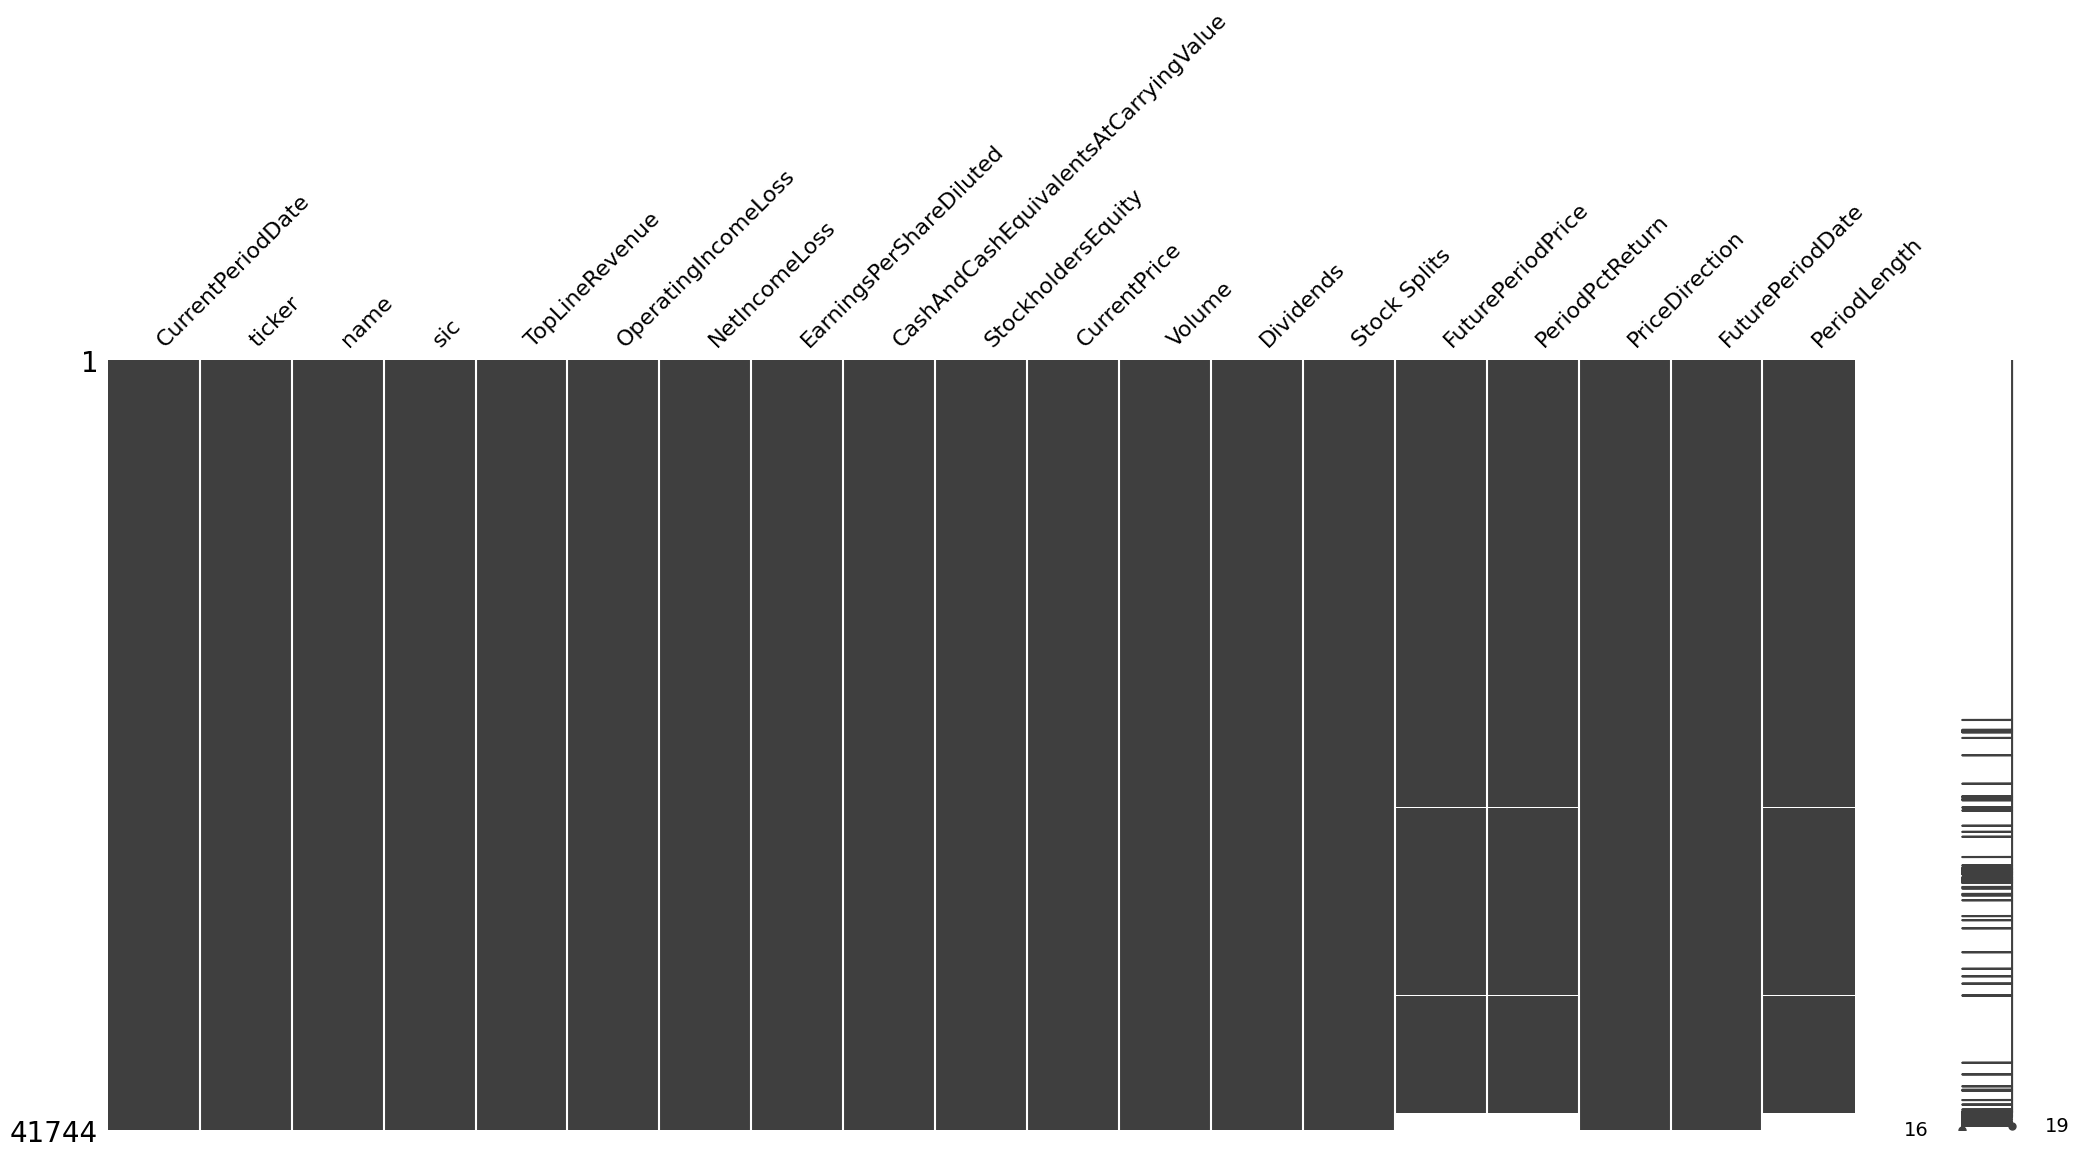

CurrentPeriodDate                        0.000000
ticker                                   0.000000
name                                     0.000000
sic                                      0.000000
TopLineRevenue                           0.000000
OperatingIncomeLoss                      0.000000
NetIncomeLoss                            0.000000
EarningsPerShareDiluted                  0.000000
CashAndCashEquivalentsAtCarryingValue    0.000000
StockholdersEquity                       0.000000
CurrentPrice                             0.000000
Volume                                   0.000000
Dividends                                0.000000
Stock Splits                             0.000000
FuturePeriodPrice                        2.407532
PeriodPctReturn                          2.407532
PriceDirection                           0.000000
FuturePeriodDate                         0.000000
PeriodLength                             2.407532
dtype: float64

In [ ]:
# Create a missing map of master_joined
msno.matrix(master_joined_dropped)
plt.show()

# Get the percentage of missing values in each column
pct_missing = master_joined_dropped.isnull().mean() * 100
pct_missing

In [ ]:
master_joined_dropped.dropna(inplace=True)

# Get the percentage of missing values in each column
pct_missing = master_joined_dropped.isnull().mean() * 100
pct_missing
len(master_joined_dropped)

40739

In [ ]:
master_joined_dropped['PeriodLength'].value_counts()

PeriodLength
3.0     39073
0.0       929
2.0       299
1.0       212
4.0       100
6.0        62
12.0       26
9.0        21
15.0        5
21.0        4
27.0        2
45.0        1
5.0         1
51.0        1
36.0        1
24.0        1
8.0         1
Name: count, dtype: int64

In [ ]:
# Create a column that calculates the average monthly compound return
master_joined_dropped['AvgMonthlyCompoundReturn'] = (
    (1 + master_joined_dropped['PeriodPctReturn']) ** (1 / master_joined_dropped['PeriodLength']) - 1
)

In [ ]:
master_joined_dropped['AvgMonthlyCompoundReturn'].describe()

count    40739.000000
mean         0.006559
std          0.077584
min         -0.566463
25%         -0.028574
50%          0.006312
75%          0.041246
max          1.500000
Name: AvgMonthlyCompoundReturn, dtype: float64

These are a preliminary estimate. More precise numbers are assigned in the EDA file

Quintile	Estimated Range (Avg Monthly Compound Return)

Q1 (Bottom 20%)	≤ -0.045 (estimated from min & Q1)

Q2 (20-40%)	-0.045 to -0.008 (between Q1 & median)

Q3 (40-60%)	-0.008 to 0.020 (around median)

Q4 (60-80%)	0.020 to 0.050 (between median & Q3)

Q5 (Top 20%)	> 0.050 (estimated from Q3 & max)

In [ ]:
# Create the target column BuySell
# Use the quintiles to segment the data
# Strong buy, buy, hold, sell, strong sell
# Label each of the above 2, 1, 0, -1, -2
master_joined_dropped['BuySell'] = master_joined_dropped['AvgMonthlyCompoundReturn'].apply(
    lambda x: 2 if x > 0.05 else 1 if x > 0.02 else 0 if x > 0.000 else -1 if x > -0.045 else -2
)

In [ ]:
master_joined_dropped.value_counts('BuySell')

BuySell
-1    11148
 2     8195
 1     7878
-2     7293
 0     6225
Name: count, dtype: int64

In [ ]:
# Head showing all columns
pd.set_option('display.max_columns', None)
master_joined_dropped.head()   

,CurrentPeriodDate,ticker,name,sic,TopLineRevenue,OperatingIncomeLoss,NetIncomeLoss,EarningsPerShareDiluted,CashAndCashEquivalentsAtCarryingValue,StockholdersEquity,CurrentPrice,Volume,Dividends,Stock Splits,FuturePeriodPrice,PeriodPctReturn,PriceDirection,FuturePeriodDate,PeriodLength,AvgMonthlyCompoundReturn,BuySell
0,201001,COST,COSTCO WHOLESALE CORP /NEW,5331.0,1.874200e+10,4.700000e+08,2.990000e+08,0.67,4.134000e+09,1.065100e+10,43.446774,72957800.0,0.18,0.0,41.636078,-0.041676,-2,201004,3.0,-0.014090,-1
1,201001,CRM,SALESFORCE COM INC,7372.0,3.540490e+08,2.551900e+07,2.039400e+07,0.16,1.011306e+09,1.043802e+09,16.893145,153820800.0,0.00,0.0,21.512344,0.273436,2,201004,3.0,0.083908,2
2,201001,HPQ,HEWLETT PACKARD CO,3570.0,3.117700e+10,3.003000e+09,2.250000e+09,0.93,1.354700e+10,4.162800e+10,15.368656,672393912.0,0.00,0.0,13.943576,-0.092726,-2,201004,3.0,-0.031917,-1
3,201001,HRB,H&R BLOCK INC,7200.0,9.348520e+08,9.444400e+07,5.063500e+07,0.15,1.727677e+09,9.364670e+08,9.832190,91390000.0,0.00,0.0,9.232124,-0.061031,-2,201004,3.0,-0.020772,-1
4,201002,ADBE,ADOBE SYSTEMS INC,7372.0,8.587000e+08,1.768330e+08,1.271540e+08,0.24,1.589442e+09,5.171420e+09,35.369999,147865800.0,0.00,0.0,26.430000,-0.252757,-2,201005,3.0,-0.092554,-2


In [ ]:
# master_joined_dropped = pd.read_csv('../data/clean/master_file.csv')

In [ ]:
# Create the final data frame with the columns we want
final_df = master_joined_dropped[['CurrentPeriodDate',
                                  'ticker', 
                                  'name',
                                  'sic',
                                  'TopLineRevenue',
                                  'OperatingIncomeLoss',
                                  'NetIncomeLoss',
                                  'EarningsPerShareDiluted',
                                  'CashAndCashEquivalentsAtCarryingValue',
                                  'StockholdersEquity',
                                  'CurrentPrice',
                                  'Volume',
                                  'Dividends',
                                  'Stock Splits', 
                                  'FuturePeriodDate', 
                                  'PeriodLength', 
                                  'FuturePeriodPrice', 
                                  'PeriodPctReturn', 
                                  'AvgMonthlyCompoundReturn', 
                                  'BuySell']]

In [ ]:
# final_df.to_csv("../data/clean/master_file.csv", index=False)

FINALLY the data set is created and it's time to do EDA.